In [15]:
# =============================================================================
# Imports
# =============================================================================

from pathlib import Path
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap

import seaborn as sns

from scipy import stats


%matplotlib inline


# =============================================================================
# Warning policy
# =============================================================================

# Clear warning filters left by earlier notebook executions.
warnings.resetwarnings()

# Keep analytical, numerical, and statistical warnings visible.
warnings.filterwarnings('default')

In [17]:
# =============================================================================
# Project-directory configuration
# =============================================================================

# Jupyter normally starts in the directory containing the notebook.
SRC_DIR = Path.cwd().resolve()

# The experiment directory is one level above src.
EXPERIMENT_DIR = SRC_DIR.parent

# Main experiment subdirectories.
RESULTS_DIR = EXPERIMENT_DIR / 'results'
BUILDING_RESULTS_DIR = RESULTS_DIR / '2_Building_2'
AGENTS_DIR = RESULTS_DIR / 'agents'

# Building-specific analysis outputs.
FIGURES_DIR = BUILDING_RESULTS_DIR / 'analysis_figures'
TABLES_DIR = BUILDING_RESULTS_DIR / 'analysis_tables'

# Create output directories when necessary.
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)


# =============================================================================
# Load the evaluated timeseries
# =============================================================================

TIMESERIES_PATH = BUILDING_RESULTS_DIR / 'timeseries.csv'

if not TIMESERIES_PATH.is_file():
    raise FileNotFoundError(f'Timeseries file was not found:\n{TIMESERIES_PATH}')

df = pd.read_csv(TIMESERIES_PATH)

if df.empty:
    raise ValueError(f'Timeseries file contains no records:\n{TIMESERIES_PATH}')

In [18]:
# =============================================================================
# Publication plotting style
# =============================================================================

# General-purpose colors
BLUE = '#2E86AB'
ORANGE = '#E07B39'
GREEN = '#27AE60'
RED = '#C0392B'
PURPLE = '#8E44AD'
TEAL = '#16A085'
GRAY = '#7F8C8D'
LIGHT_GRAY = '#ECF0F1'

# Meaning-specific colors
COLOR_TD3 = '#1F77B4'
COLOR_BASELINE = '#D62728'
COLOR_PV = '#2CA02C'
COLOR_ACCENT = '#FF7F0E'

# Additional physical-variable colors
COLOR_LOAD = '#4D4D4D'
COLOR_BATTERY = '#FF7F0E'
COLOR_GRID_IMPORT = '#2E86AB'
COLOR_GRID_EXPORT = '#E07B39'
COLOR_PRICE = '#8E44AD'
COLOR_CARBON = '#16A085'


# =============================================================================
# Global Matplotlib settings
# =============================================================================

plt.rcParams.update({
    # Font
    'font.family': 'DejaVu Sans',
    'font.size': 10,

    # Axes
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'axes.labelsize': 10,
    'axes.facecolor': 'white',

    # Grid
    'grid.color': '#E8E8E8',
    'grid.linewidth': 0.6,

    # Tick labels
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,

    # Legend
    'legend.fontsize': 9,
    'legend.framealpha': 0.85,
    'legend.edgecolor': '#CCCCCC',

    # Figure display
    'figure.dpi': 150,
    'figure.facecolor': 'white',

    # Saved figures
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.facecolor': 'white',
})


# =============================================================================
# Figure-saving function
# =============================================================================

def save_figure(
    fig,
    name,
    save_png=True,
    save_pdf=True,
    show=True,
    close=True,
):
    """
    Save a Matplotlib figure in the analysis_figures directory.

    Parameters
    ----------
    fig : matplotlib.figure.Figure
        Matplotlib figure to save.

    name : str or Path
        Filename or filename stem, such as 'soc_profile' or
        'soc_profile.png'.

    save_png : bool, default=True
        Save a 300-dpi PNG copy.

    save_pdf : bool, default=True
        Save a vector PDF copy.

    show : bool, default=True
        Display the figure inside the notebook.

    close : bool, default=True
        Close the figure after saving and displaying.
    """

    if fig is None:
        raise ValueError('A valid Matplotlib figure must be supplied.')

    FIGURES_DIR.mkdir(parents=True,exist_ok=True,)

    figure_stem = Path(name).stem

    if not figure_stem:
        raise ValueError('The figure name cannot be empty.')
    saved_paths = []
    if save_png:
        png_path = FIGURES_DIR / f'{figure_stem}.png'

        fig.savefig(
            png_path,
            dpi=300,
            bbox_inches='tight',
            facecolor='white',)

        saved_paths.append(png_path)

    if save_pdf:
        pdf_path = FIGURES_DIR / f'{figure_stem}.pdf'
        fig.savefig(pdf_path,bbox_inches='tight',facecolor='white',)
        saved_paths.append(pdf_path)

    if not saved_paths:
        raise ValueError('At least one output format must be enabled.')

    for saved_path in saved_paths:
        print(f'Saved: {saved_path}')

    if show:
        plt.show()

    if close:
        plt.close(fig)

    return saved_paths

In [20]:
# =============================================================================
# Timeseries schema and data-integrity validation
# =============================================================================

REQUIRED_COLUMNS = [
    'transition',
    'action_time_step',
    'reward_time_step',
    'environment_time_step_after_action',
    'action',
    'reward',
    'pre_action_soc',
    'post_action_soc',
    'load',
    'pv_generation',
    'base_net_demand',
    'battery_consumption',
    'net_consumption',
    'grid_import',
    'grid_export',
    'unavoidable_export',
    'avoidable_export',
    'electricity_price',
    'carbon_intensity',
    'raw_grid_penalty',
    'raw_cost',
    'raw_emission',
    'normalized_grid',
    'normalized_cost',
    'normalized_emission',
    'weighted_grid',
    'weighted_cost',
    'weighted_emission',
    'terminal_soc_penalty',
    'net_baseline',
    'baseline_grid_import',
    'positive_baseline_cost',
    'positive_baseline_emission',
]


def validate_timeseries(
    timeseries,
    expected_transitions=None,
    atol=1e-8,
    rtol=1e-6,
):
    """
    Validate one complete corrected evaluation episode.

    The function reports structural, timing, physical,
    reward, and SOC-continuity checks without modifying
    the raw timeseries.
    """

    missing_columns = [
        column
        for column in REQUIRED_COLUMNS
        if column not in timeseries.columns
    ]

    if missing_columns:
        raise KeyError(
            'Required timeseries columns are missing:\n'
            f'{missing_columns}'
        )

    if timeseries.empty:
        raise ValueError(
            'The timeseries contains no transitions.'
        )

    numeric_data = timeseries.select_dtypes(
        include=[np.number],
    )

    nan_count = int(timeseries.isna().sum().sum())
    infinite_count = int(
        np.isinf(numeric_data.to_numpy()).sum()
    )

    checks = {
        'No missing values':
            nan_count == 0,

        'No infinite values':
            infinite_count == 0,

        'Unique transition identifiers':
            not timeseries['transition'].duplicated().any(),

        'Continuous transition identifiers':
            timeseries['transition'].equals(
                pd.Series(
                    np.arange(len(timeseries)),
                    index=timeseries.index,
                    name='transition',
                )
            ),

        'Transition equals action time step':
            (
                timeseries['transition']
                == timeseries['action_time_step']
            ).all(),

        'Corrected transition timing':
            (
                timeseries['reward_time_step']
                == timeseries['action_time_step'] + 1
            ).all(),

        'Environment post-action time alignment':
            (
                timeseries[
                    'environment_time_step_after_action'
                ]
                == timeseries['reward_time_step']
            ).all(),

        'Base-net-demand identity':
            np.allclose(
                timeseries['base_net_demand'],
                (
                    timeseries['load']
                    - timeseries['pv_generation']
                ),
                atol=atol,
                rtol=rtol,
            ),

        'Net-consumption identity':
            np.allclose(
                timeseries['net_consumption'],
                (
                    timeseries['base_net_demand']
                    + timeseries['battery_consumption']
                ),
                atol=atol,
                rtol=rtol,
            ),

        'Grid-import identity':
            np.allclose(
                timeseries['grid_import'],
                np.maximum(
                    timeseries['net_consumption'],
                    0.0,
                ),
                atol=atol,
                rtol=rtol,
            ),

        'Grid-export identity':
            np.allclose(
                timeseries['grid_export'],
                np.maximum(
                    -timeseries['net_consumption'],
                    0.0,
                ),
                atol=atol,
                rtol=rtol,
            ),

        'Unavoidable-export identity':
            np.allclose(
                timeseries['unavoidable_export'],
                np.maximum(
                    -timeseries['projected_grid_target'],
                    0.0,
                ),
                atol=atol,
                rtol=rtol,
            ),

        'Avoidable-export identity':
            np.allclose(
                timeseries['avoidable_export'],
                np.maximum(
                    (
                        timeseries['grid_export']
                        - timeseries['unavoidable_export']
                    ),
                    0.0,
                ),
                atol=atol,
                rtol=rtol,
            ),

        'Raw-cost identity':
            np.allclose(
                timeseries['raw_cost'],
                (
                    timeseries['grid_import']
                    * timeseries['electricity_price']
                ),
                atol=atol,
                rtol=rtol,
            ),

        'Raw-emission identity':
            np.allclose(
                timeseries['raw_emission'],
                (
                    timeseries['grid_import']
                    * timeseries['carbon_intensity']
                ),
                atol=atol,
                rtol=rtol,
            ),

        'Reward identity':
            np.allclose(
                timeseries['reward'],
                -(
                    timeseries['weighted_grid']
                    + timeseries['weighted_cost']
                    + timeseries['weighted_emission']
                )
                + timeseries['terminal_soc_penalty'],
                atol=atol,
                rtol=rtol,
            ),
    }

    soc_continuity = np.allclose(
        timeseries['pre_action_soc'].iloc[1:].to_numpy(),
        timeseries['post_action_soc'].iloc[:-1].to_numpy(),
        atol=atol,
        rtol=rtol,
    )

    checks['Inter-transition SOC continuity'] = soc_continuity

    if expected_transitions is not None:
        checks['Expected transition count'] = (
            len(timeseries) == expected_transitions
        )

    validation_report = pd.DataFrame({
        'check': list(checks.keys()),
        'passed': list(checks.values()),
    })

    validation_report['status'] = np.where(
        validation_report['passed'],
        'PASS',
        'FAIL',
    )

    return validation_report
# ══════════════════════════════════════════════════════════════════════════════
# ══════════════════════════════════════════════════════════════════════════════
validation_report = validate_timeseries(
    df,
    expected_transitions=8759,
)

display(validation_report)
# ══════════════════════════════════════════════════════════════════════════════
# ══════════════════════════════════════════════════════════════════════════════
validation_report.to_csv(
    TABLES_DIR / 'timeseries_validation_report.csv',
    index=False,
)

,check,passed,status
0,No missing values,True,PASS
1,No infinite values,True,PASS
2,Unique transition identifiers,True,PASS
3,Continuous transition identifiers,False,FAIL
4,Transition equals action time step,True,PASS
5,Corrected transition timing,True,PASS
6,Environment post-action time alignment,True,PASS
7,Base-net-demand identity,True,PASS
8,Net-consumption identity,True,PASS
9,Grid-import identity,True,PASS


c:\Users\arif\Anaconda3\envs\marlin23_1\lib\site-packages\ipykernel_launcher.py:859: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


Saved: D:\CityLearn\12_Transfer learning\0_28July_IF_U\6_standrad\results\2_Building_2\analysis_figures\plot01_cumulative_kpis_with_zoomed_insets.png
Saved: D:\CityLearn\12_Transfer learning\0_28July_IF_U\6_standrad\results\2_Building_2\analysis_figures\plot01_cumulative_kpis_with_zoomed_insets.pdf


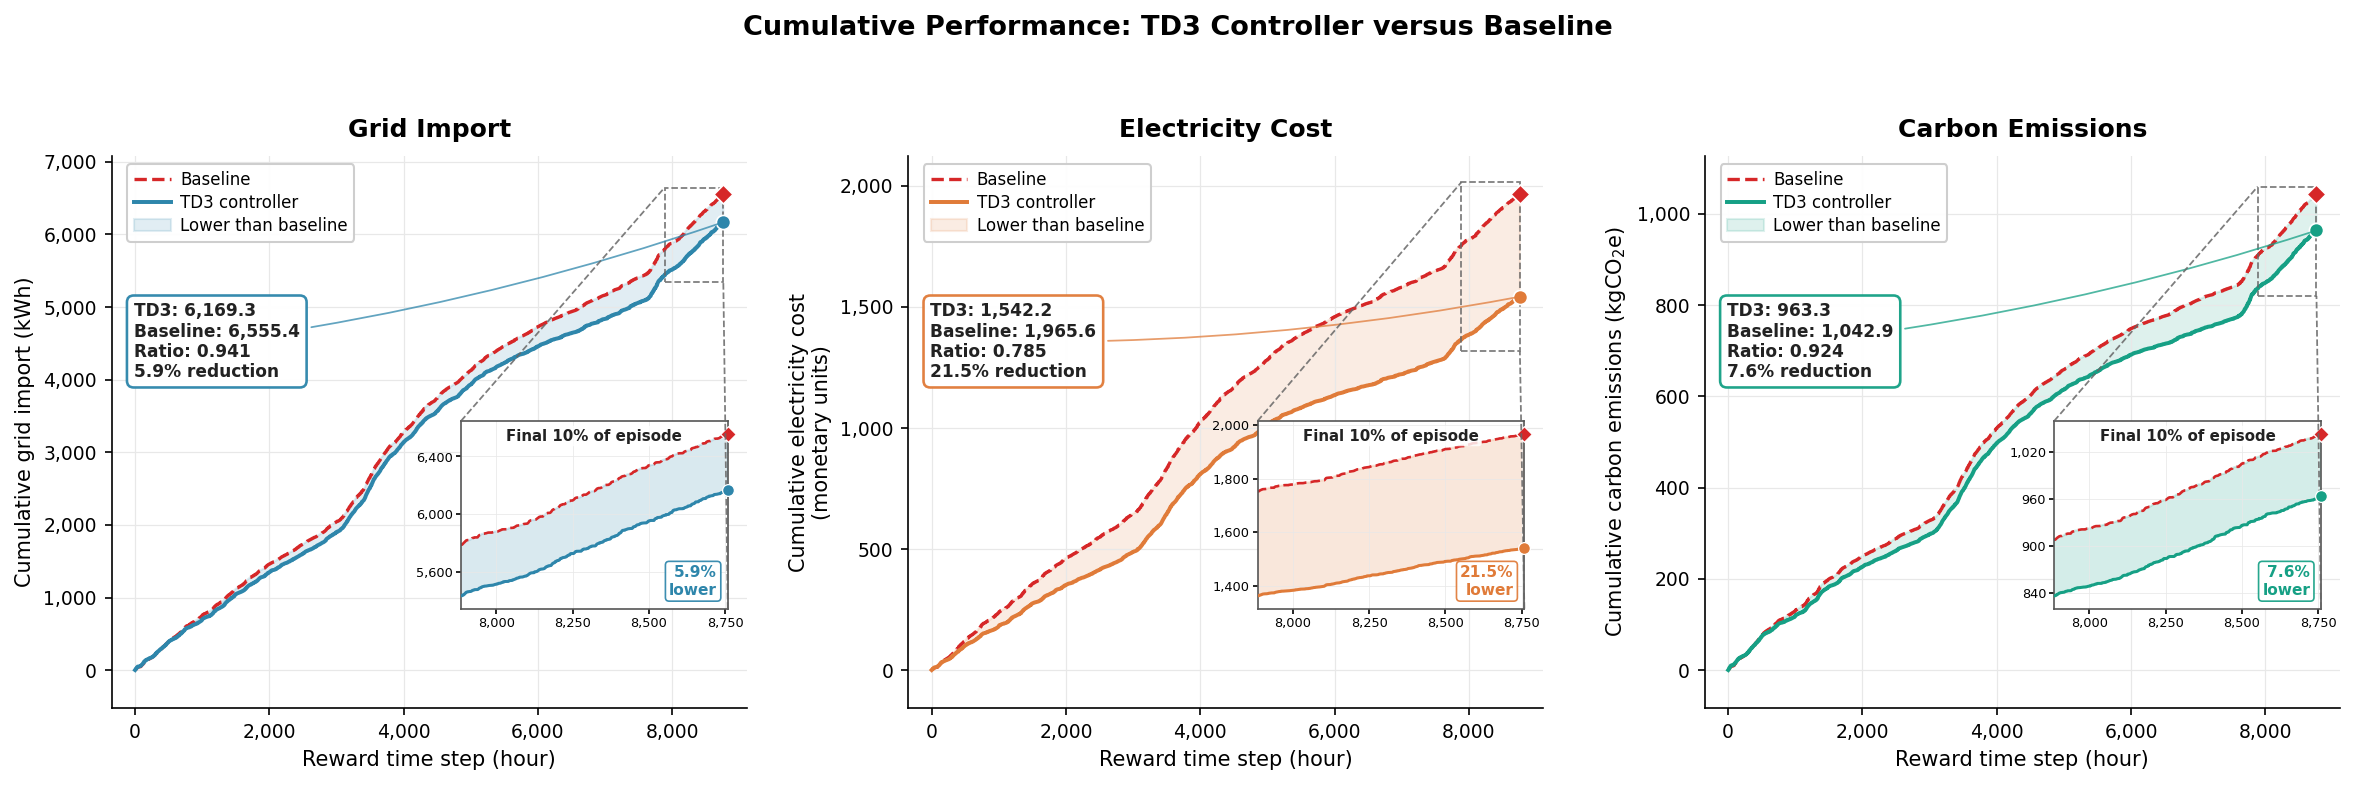

,metric,controller_column,baseline_column,td3_total,baseline_total,baseline_minus_td3,td3_to_baseline_ratio,percentage_reduction,unit,zoom_start_time_step,zoom_end_time_step
0,Grid Import,grid_import,baseline_grid_import,6169.328754,6555.447159,386.118405,0.941100,5.890039,kWh,7884.0,8759.0
1,Electricity Cost,raw_cost,positive_baseline_cost,1542.207816,1965.643488,423.435672,0.784582,21.541835,monetary units,7884.0,8759.0
2,Carbon Emissions,raw_emission,positive_baseline_emission,963.299771,1042.943169,79.643398,0.923636,7.636408,kgCO$_2$e,7884.0,8759.0


Plot 1 numerical summary saved to:
D:\CityLearn\12_Transfer learning\0_28July_IF_U\6_standrad\results\2_Building_2\analysis_tables\plot01_cumulative_kpis_with_zoomed_insets_summary.csv


In [ ]:
# =============================================================================
# Plot 1: Cumulative physical KPIs with final-period zoomed insets
# =============================================================================

# This figure describes one complete evaluation episode.
# It illustrates temporal accumulation but does not represent
# multi-seed uncertainty or statistical significance.

from mpl_toolkits.axes_grid1.inset_locator import (
    inset_axes,
    mark_inset,
)


TIME_COLUMN = 'reward_time_step'

# Fraction of the complete evaluation horizon shown in each inset.
# A value of 0.10 means that the final 10% of the episode is enlarged.
ZOOM_FRACTION = 0.10


# =============================================================================
# Plot configuration
# =============================================================================

kpi_pairs = [
    {
        'controller': 'grid_import',
        'baseline': 'baseline_grid_import',
        'ylabel': 'Cumulative grid import (kWh)',
        'title': 'Grid Import',
        'color': COLOR_GRID_IMPORT,
        'unit': 'kWh',
    },
    {
        'controller': 'raw_cost',
        'baseline': 'positive_baseline_cost',
        'ylabel': (
            'Cumulative electricity cost\n'
            '(monetary units)'
        ),
        'title': 'Electricity Cost',
        'color': ORANGE,
        'unit': 'monetary units',
    },
    {
        'controller': 'raw_emission',
        'baseline': 'positive_baseline_emission',
        'ylabel': (
            'Cumulative carbon emissions '
            '(kgCO$_2$e)'
        ),
        'title': 'Carbon Emissions',
        'color': COLOR_CARBON,
        'unit': 'kgCO$_2$e',
    },
]


# KPI summary boxes are positioned below the upper-left legends.
summary_box_positions = {
    'Grid Import': (0.035, 0.735),
    'Electricity Cost': (0.035, 0.735),
    'Carbon Emissions': (0.035, 0.735),
}


# Inset positions are expressed in parent-axis fractional coordinates:
#
# (left position, bottom position, width, height)
#
# The bottom position is raised to prevent the inset tick labels from
# overlapping with the main x-axis tick labels and x-axis title.
inset_positions = {
    'Grid Import': (0.55, 0.18, 0.42, 0.34),
    'Electricity Cost': (0.55, 0.18, 0.42, 0.34),
    'Carbon Emissions': (0.55, 0.18, 0.42, 0.34),
}


# =============================================================================
# Validate plot configuration
# =============================================================================

if not 0.0 < ZOOM_FRACTION < 1.0:
    raise ValueError(
        'ZOOM_FRACTION must be strictly between 0 and 1.'
    )


required_plot_columns = {
    TIME_COLUMN,
}

for item in kpi_pairs:
    required_plot_columns.add(
        item['controller']
    )
    required_plot_columns.add(
        item['baseline']
    )


missing_plot_columns = sorted(
    required_plot_columns - set(df.columns)
)

if missing_plot_columns:
    raise KeyError(
        'The cumulative-KPI plot cannot be generated because '
        'the following columns are missing:\n'
        f'{missing_plot_columns}'
    )


# Confirm that all plotted columns contain finite numerical values.
non_finite_columns = []

for column in sorted(required_plot_columns):

    column_values = df[column].to_numpy(
        dtype=float
    )

    if not np.isfinite(column_values).all():
        non_finite_columns.append(
            column
        )


if non_finite_columns:
    raise ValueError(
        'NaN or infinite values were detected in the '
        'following plot columns:\n'
        f'{non_finite_columns}'
    )


# =============================================================================
# Validate the time axis
# =============================================================================

time_values = df[
    TIME_COLUMN
].astype(float)


if not time_values.is_monotonic_increasing:
    raise ValueError(
        f'{TIME_COLUMN} is not monotonically increasing.'
    )


if time_values.duplicated().any():
    raise ValueError(
        f'{TIME_COLUMN} contains duplicated values.'
    )


# =============================================================================
# Determine the zoomed evaluation interval
# =============================================================================

number_of_transitions = len(df)

zoom_start_index = max(
    0,
    int(
        np.floor(
            number_of_transitions
            * (1.0 - ZOOM_FRACTION)
        )
    ),
)

zoom_start_time = float(
    time_values.iloc[
        zoom_start_index
    ]
)

zoom_end_time = float(
    time_values.iloc[-1]
)


# =============================================================================
# Create the main figure
# =============================================================================

fig, axes = plt.subplots(
    nrows=1,
    ncol=3,
    figsize=(15.8, 5.4),
    sharex=True,
)


# Store the numerical values used in the figure.
plot_summary_records = []


# =============================================================================
# Generate each KPI panel
# =============================================================================

for ax, item in zip(
    axes,
    kpi_pairs,
):

    # -------------------------------------------------------------------------
    # Calculate cumulative trajectories
    # -------------------------------------------------------------------------

    controller_cumulative = (
        df[item['controller']]
        .cumsum()
        .astype(float)
    )

    baseline_cumulative = (
        df[item['baseline']]
        .cumsum()
        .astype(float)
    )


    # -------------------------------------------------------------------------
    # Calculate final episode-level values
    # -------------------------------------------------------------------------

    controller_total = float(
        controller_cumulative.iloc[-1]
    )

    baseline_total = float(
        baseline_cumulative.iloc[-1]
    )

    final_difference = (
        baseline_total
        - controller_total
    )

    final_time = float(
        time_values.iloc[-1]
    )


    # -------------------------------------------------------------------------
    # Calculate final ratio and percentage change
    # -------------------------------------------------------------------------

    if np.isclose(
        baseline_total,
        0.0,
        atol=1e-12,
    ):
        final_ratio = np.nan
        percentage_reduction = np.nan

        change_label = 'Percentage change undefined'

        annotation_text = (
            f'TD3: {controller_total:,.1f}\n'
            f'Baseline: {baseline_total:,.1f}\n'
            'Ratio: undefined'
        )

    else:
        final_ratio = (
            controller_total
            / baseline_total
        )

        percentage_reduction = (
            100.0
            * final_difference
            / baseline_total
        )

        if percentage_reduction >= 0.0:
            change_label = (
                f'{percentage_reduction:.1f}% reduction'
            )
        else:
            change_label = (
                f'{abs(percentage_reduction):.1f}% increase'
            )

        annotation_text = (
            f'TD3: {controller_total:,.1f}\n'
            f'Baseline: {baseline_total:,.1f}\n'
            f'Ratio: {final_ratio:.3f}\n'
            f'{change_label}'
        )


    # -------------------------------------------------------------------------
    # Store numerical results for table export
    # -------------------------------------------------------------------------

    plot_summary_records.append({
        'metric': item['title'],
        'controller_column': item['controller'],
        'baseline_column': item['baseline'],
        'td3_total': controller_total,
        'baseline_total': baseline_total,
        'baseline_minus_td3': final_difference,
        'td3_to_baseline_ratio': final_ratio,
        'percentage_reduction': percentage_reduction,
        'unit': item['unit'],
        'zoom_start_time_step': zoom_start_time,
        'zoom_end_time_step': zoom_end_time,
    })


    # -------------------------------------------------------------------------
    # Plot the baseline cumulative trajectory
    # -------------------------------------------------------------------------

    ax.plot(
        time_values,
        baseline_cumulative,
        color=COLOR_BASELINE,
        linewidth=1.6,
        linestyle='--',
        label='Baseline',
        zorder=2,
    )


    # -------------------------------------------------------------------------
    # Plot the TD3 cumulative trajectory
    # -------------------------------------------------------------------------

    ax.plot(
        time_values,
        controller_cumulative,
        color=item['color'],
        linewidth=1.9,
        linestyle='-',
        label='TD3 controller',
        zorder=3,
    )


    # -------------------------------------------------------------------------
    # Shade regions where TD3 remains cumulatively below baseline
    # -------------------------------------------------------------------------

    improvement_mask = (
        controller_cumulative
        < baseline_cumulative
    )

    ax.fill_between(
        time_values,
        controller_cumulative,
        baseline_cumulative,
        where=improvement_mask,
        interpolate=True,
        color=item['color'],
        alpha=0.14,
        label='Lower than baseline',
        zorder=1,
    )


    # -------------------------------------------------------------------------
    # Mark the final baseline and TD3 values on the main plot
    # -------------------------------------------------------------------------

    ax.scatter(
        final_time,
        baseline_total,
        color=COLOR_BASELINE,
        marker='D',
        s=42,
        edgecolor='white',
        linewidth=0.8,
        zorder=6,
        clip_on=False,
    )

    ax.scatter(
        final_time,
        controller_total,
        color=item['color'],
        marker='o',
        s=46,
        edgecolor='white',
        linewidth=0.8,
        zorder=7,
        clip_on=False,
    )


    # -------------------------------------------------------------------------
    # Place the legend at the top-left
    # -------------------------------------------------------------------------

    ax.legend(
        loc='upper left',
        bbox_to_anchor=(
            0.025,
            0.985,
        ),
        borderaxespad=0.0,
        frameon=True,
        framealpha=0.95,
        facecolor='white',
        edgecolor='#CCCCCC',
        fontsize=8,
        labelspacing=0.30,
        handlelength=2.2,
        handletextpad=0.55,
    )


    # -------------------------------------------------------------------------
    # Add the numerical KPI box below the legend
    # -------------------------------------------------------------------------

    ax.annotate(
        annotation_text,

        # Connect the summary box with the final TD3 point.
        xy=(
            final_time,
            controller_total,
        ),

        # Position the box directly below the legend.
        xytext=summary_box_positions[
            item['title']
        ],

        xycoords='data',
        textcoords='axes fraction',

        horizontalalignment='left',
        verticalalignment='top',

        fontsize=8.2,
        fontweight='bold',
        linespacing=1.15,
        color='#222222',

        bbox={
            'boxstyle': 'round,pad=0.40',
            'facecolor': 'white',
            'edgecolor': item['color'],
            'linewidth': 1.25,
            'alpha': 0.96,
        },

        arrowprops={
            'arrowstyle': '-',
            'color': item['color'],
            'linewidth': 0.85,
            'alpha': 0.75,
            'connectionstyle': 'arc3,rad=0.05',
        },

        zorder=8,
    )


    # =========================================================================
    # Create a raised inset showing the final 10% of the episode
    # =========================================================================

    inset_left, inset_bottom, inset_width, inset_height = (
        inset_positions[
            item['title']
        ]
    )

    inset_ax = inset_axes(
        ax,
        width='100%',
        height='100%',
        loc='lower left',
        bbox_to_anchor=(
            inset_left,
            inset_bottom,
            inset_width,
            inset_height,
        ),
        bbox_transform=ax.transAxes,
        borderpad=0.0,
    )


    # -------------------------------------------------------------------------
    # Plot the cumulative trajectories inside the inset
    # -------------------------------------------------------------------------

    inset_ax.plot(
        time_values,
        baseline_cumulative,
        color=COLOR_BASELINE,
        linewidth=1.25,
        linestyle='--',
        zorder=2,
    )

    inset_ax.plot(
        time_values,
        controller_cumulative,
        color=item['color'],
        linewidth=1.45,
        linestyle='-',
        zorder=3,
    )

    inset_ax.fill_between(
        time_values,
        controller_cumulative,
        baseline_cumulative,
        where=improvement_mask,
        interpolate=True,
        color=item['color'],
        alpha=0.18,
        zorder=1,
    )


    # -------------------------------------------------------------------------
    # Extract the data included in the zoomed interval
    # -------------------------------------------------------------------------

    zoom_controller_values = (
        controller_cumulative.iloc[
            zoom_start_index:
        ]
    )

    zoom_baseline_values = (
        baseline_cumulative.iloc[
            zoom_start_index:
        ]
    )

    zoom_all_values = np.concatenate([
        zoom_controller_values.to_numpy(
            dtype=float
        ),
        zoom_baseline_values.to_numpy(
            dtype=float
        ),
    ])


    zoom_y_min = float(
        np.min(
            zoom_all_values
        )
    )

    zoom_y_max = float(
        np.max(
            zoom_all_values
        )
    )

    zoom_y_range = (
        zoom_y_max
        - zoom_y_min
    )


    # -------------------------------------------------------------------------
    # Add vertical spacing around the zoomed values
    # -------------------------------------------------------------------------

    if np.isclose(
        zoom_y_range,
        0.0,
        atol=1e-12,
    ):
        zoom_y_padding = max(
            abs(zoom_y_max) * 0.03,
            1.0,
        )
    else:
        zoom_y_padding = (
            0.08
            * zoom_y_range
        )


    inset_ax.set_xlim(
        zoom_start_time,
        zoom_end_time,
    )

    inset_ax.set_ylim(
        zoom_y_min - zoom_y_padding,
        zoom_y_max + zoom_y_padding,
    )


    # -------------------------------------------------------------------------
    # Mark final values inside the inset
    # -------------------------------------------------------------------------

    inset_ax.scatter(
        final_time,
        baseline_total,
        color=COLOR_BASELINE,
        marker='D',
        s=28,
        edgecolor='white',
        linewidth=0.6,
        zorder=5,
        clip_on=False,
    )

    inset_ax.scatter(
        final_time,
        controller_total,
        color=item['color'],
        marker='o',
        s=32,
        edgecolor='white',
        linewidth=0.6,
        zorder=6,
        clip_on=False,
    )


    # -------------------------------------------------------------------------
    # Add final percentage change inside the inset
    # -------------------------------------------------------------------------

    if np.isfinite(
        percentage_reduction
    ):
        if percentage_reduction >= 0.0:
            inset_change_text = (
                f'{percentage_reduction:.1f}%\n'
                'lower'
            )

            inset_change_color = (
                item['color']
            )

        else:
            inset_change_text = (
                f'{abs(percentage_reduction):.1f}%\n'
                'higher'
            )

            inset_change_color = RED

    else:
        inset_change_text = (
            'Change\nundefined'
        )

        inset_change_color = GRAY


    inset_ax.text(
        0.96,
        0.06,
        inset_change_text,

        transform=inset_ax.transAxes,

        horizontalalignment='right',
        verticalalignment='bottom',

        fontsize=7.4,
        fontweight='bold',

        color=inset_change_color,

        bbox={
            'boxstyle': 'round,pad=0.24',
            'facecolor': 'white',
            'edgecolor': inset_change_color,
            'linewidth': 0.8,
            'alpha': 0.93,
        },

        zorder=8,
    )


    # -------------------------------------------------------------------------
    # Place inset title inside the inset
    # -------------------------------------------------------------------------

    inset_ax.text(
        0.50,
        0.96,
        'Final 10% of episode',

        transform=inset_ax.transAxes,

        horizontalalignment='center',
        verticalalignment='top',

        fontsize=7.2,
        fontweight='bold',
        color='#222222',

        bbox={
            'boxstyle': 'round,pad=0.18',
            'facecolor': 'white',
            'edgecolor': 'none',
            'alpha': 0.82,
        },

        zorder=10,
    )


    # -------------------------------------------------------------------------
    # Format inset ticks and grid
    # -------------------------------------------------------------------------

    inset_ax.tick_params(
        axis='both',
        which='major',
        labelsize=6.2,
        length=2.3,
        pad=1.5,
    )

    inset_ax.xaxis.set_major_locator(
        ticker.MaxNLocator(
            nbins=4,
            integer=True,
        )
    )

    inset_ax.yaxis.set_major_locator(
        ticker.MaxNLocator(
            nbins=4,
        )
    )

    inset_ax.xaxis.set_major_formatter(
        ticker.StrMethodFormatter(
            '{x:,.0f}'
        )
    )

    inset_ax.yaxis.set_major_formatter(
        ticker.StrMethodFormatter(
            '{x:,.0f}'
        )
    )

    inset_ax.grid(
        True,
        color='#E8E8E8',
        linewidth=0.45,
        alpha=0.8,
    )

    # The inset does not need separate axis titles.
    inset_ax.set_xlabel('')
    inset_ax.set_ylabel('')


    # Keep all four boundaries visible around the inset.
    for spine in inset_ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.8)
        spine.set_color('#555555')


    # -------------------------------------------------------------------------
    # Draw dashed zoom rectangle and connector lines
    # -------------------------------------------------------------------------

    mark_inset(
        ax,
        inset_ax,
        loc1=2,
        loc2=4,
        facecolor='none',
        edgecolor='#666666',
        linewidth=0.85,
        linestyle='--',
        alpha=0.85,
        zorder=5,
    )


    # -------------------------------------------------------------------------
    # Format the main axes
    # -------------------------------------------------------------------------

    ax.set_xlabel(
        'Reward time step (hour)'
    )

    ax.set_ylabel(
        item['ylabel']
    )

    ax.set_title(
        item['title'],
        pad=9,
    )

    ax.xaxis.set_major_locator(
        ticker.MaxNLocator(
            nbins=5,
            integer=True,
        )
    )

    ax.xaxis.set_major_formatter(
        ticker.StrMethodFormatter(
            '{x:,.0f}'
        )
    )

    ax.yaxis.set_major_formatter(
        ticker.StrMethodFormatter(
            '{x:,.0f}'
        )
    )

    # Add enough horizontal and vertical margin for final markers.
    ax.margins(
        x=0.04,
        y=0.08,
    )


# =============================================================================
# Final figure formatting
# =============================================================================

fig.suptitle(
    'Cumulative Performance: TD3 Controller versus Baseline',
    fontsize=13,
    fontweight='bold',
    y=0.995,
)

fig.tight_layout(
    rect=[
        0.0,
        0.035,
        1.0,
        0.955,
    ],
    w_pad=2.0,
)


# =============================================================================
# Save the figure
# =============================================================================

save_figure(
    fig,
    'plot01_cumulative_kpis_with_zoomed_insets',
)


# =============================================================================
# Save and display the numerical summary
# =============================================================================

plot01_summary = pd.DataFrame(
    plot_summary_records
)

plot01_summary_path = (
    TABLES_DIR
    / 'plot01_cumulative_kpis_with_zoomed_insets_summary.csv'
)

plot01_summary.to_csv(
    plot01_summary_path,
    index=False,
)

display(
    plot01_summary
)

print(
    'Plot 1 numerical summary saved to:\n'
    f'{plot01_summary_path}'
)

Verified electricity-price values: [0.21, 0.22, 0.4, 0.5, 0.54]
Peak-tariff intervals in Week 20:
  Hour 15 to 20
  Hour 39 to 44
  Hour 63 to 68
  Hour 87 to 92
  Hour 111 to 116
  Hour 135 to 140
  Hour 159 to 164
Saved: D:\CityLearn\12_Transfer learning\0_28July_IF_U\6_standrad\results\2_Building_2\analysis_figures\plot03_weekly_operational_profile_week_20_with_peak_tariff.png
Saved: D:\CityLearn\12_Transfer learning\0_28July_IF_U\6_standrad\results\2_Building_2\analysis_figures\plot03_weekly_operational_profile_week_20_with_peak_tariff.pdf


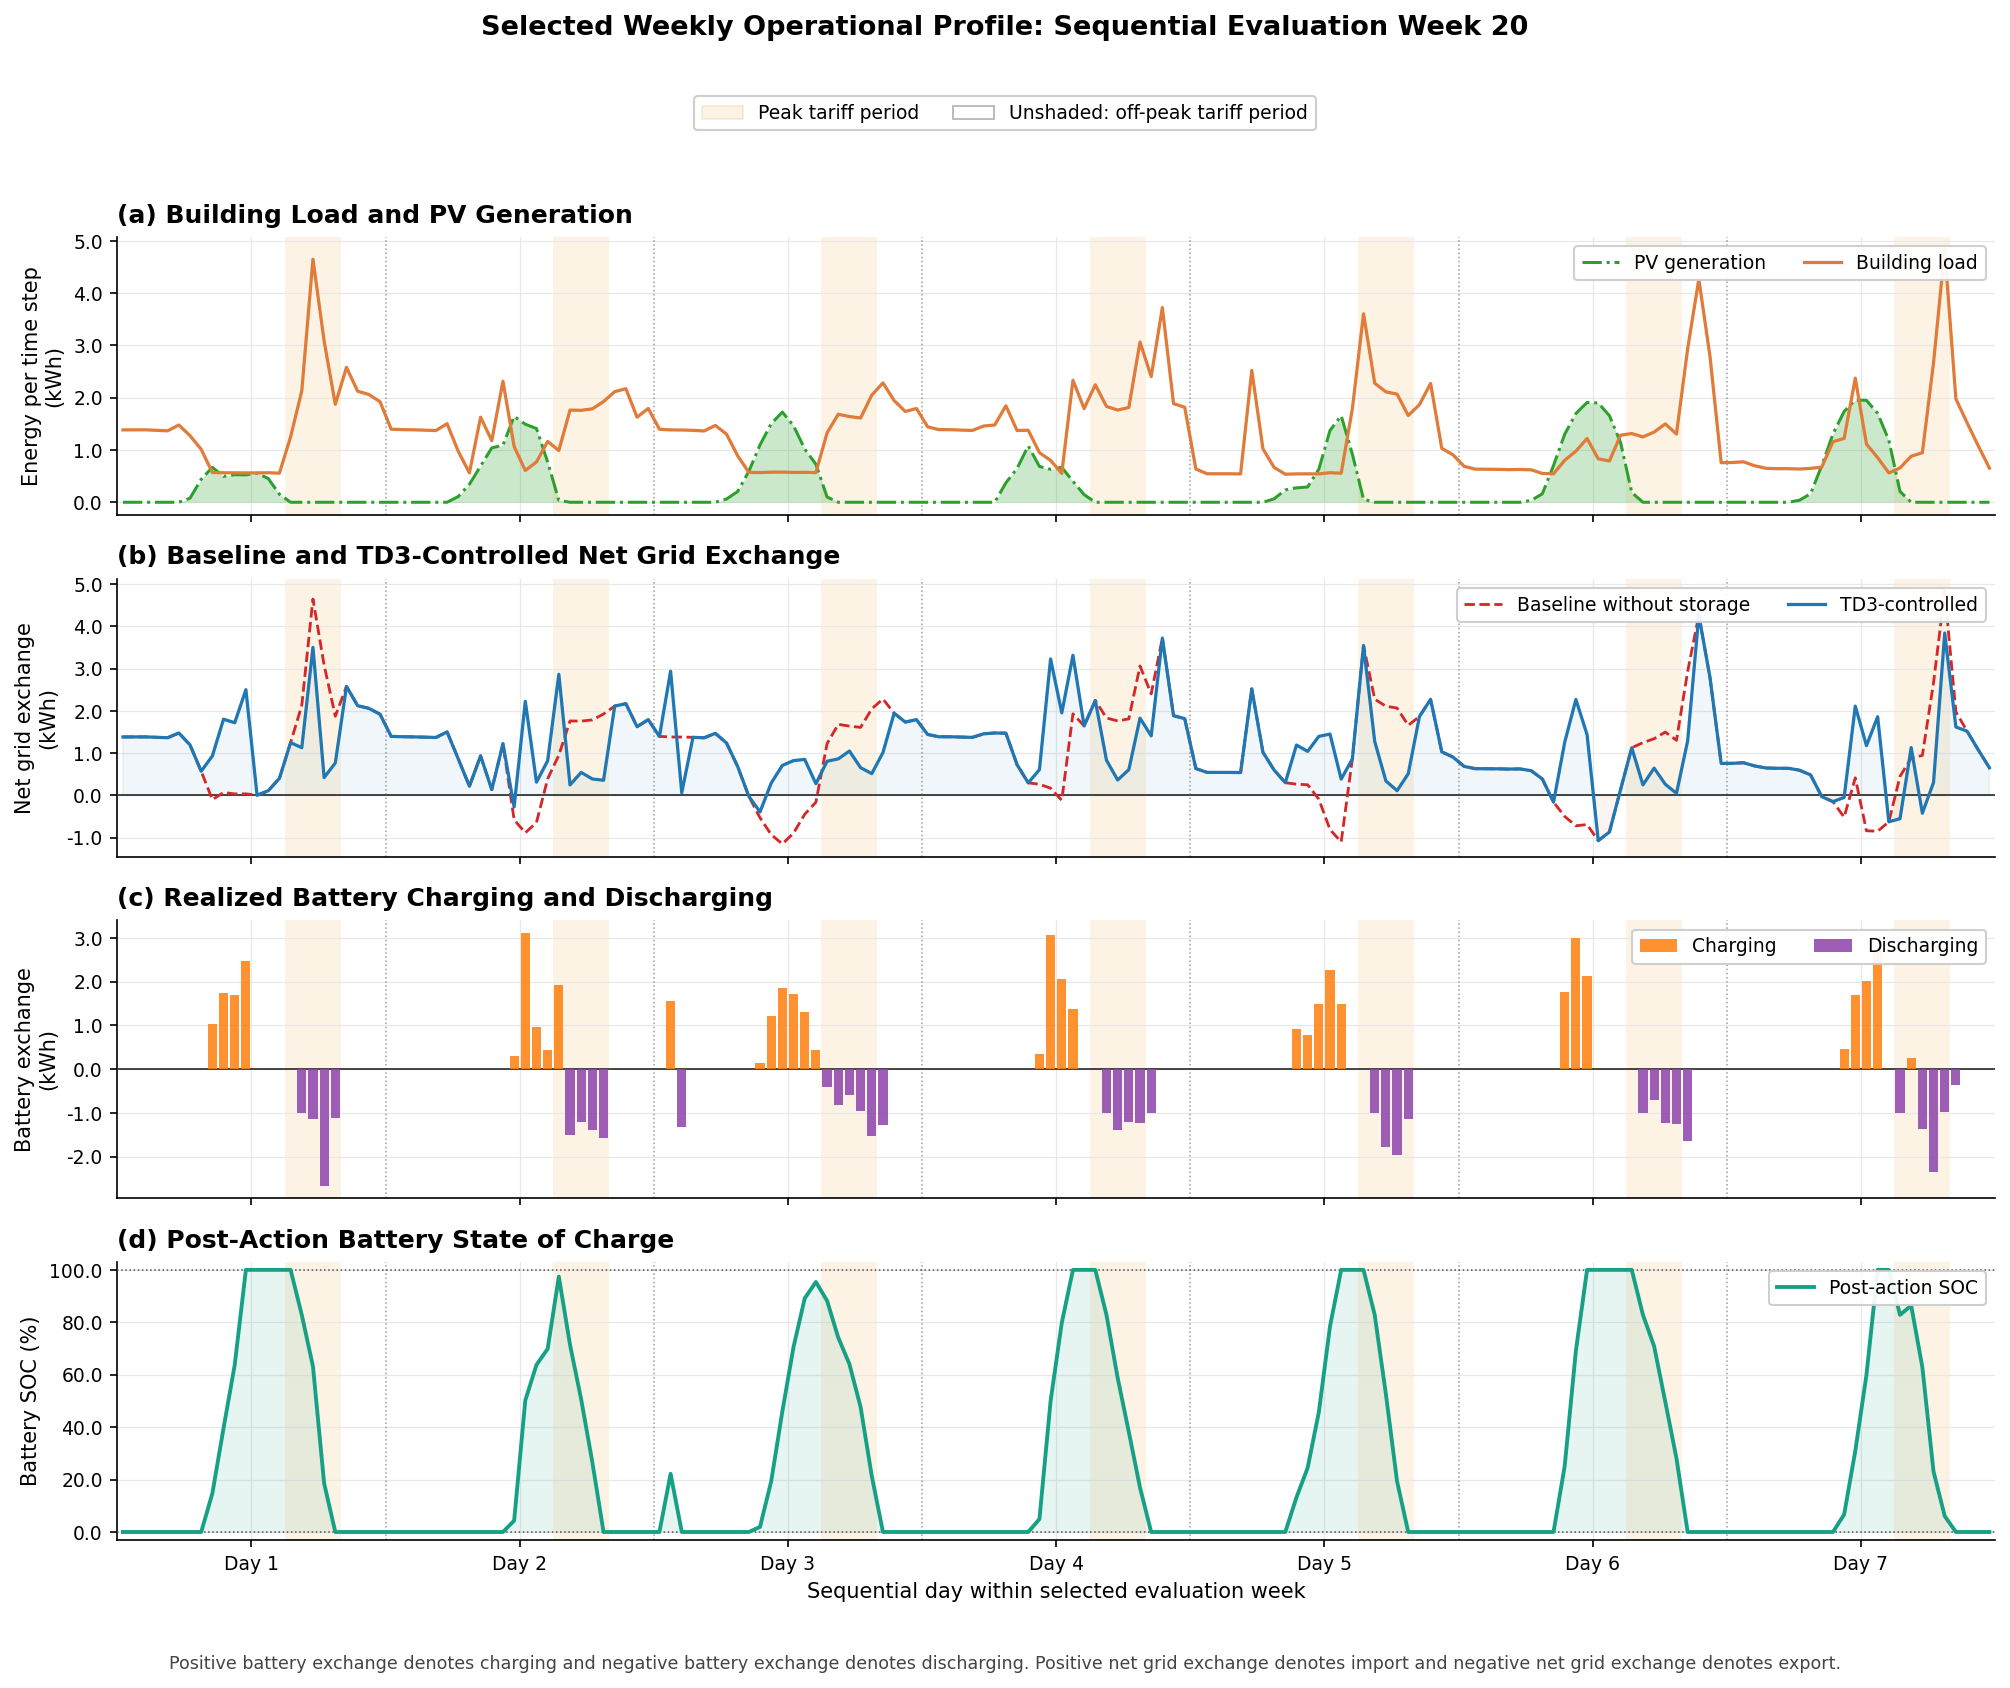

,selected_week,start_transition,end_transition,start_reward_time_step,end_reward_time_step,number_of_transitions,total_load_kwh,total_pv_generation_kwh,baseline_grid_import_kwh,controlled_grid_import_kwh,...,baseline_grid_export_kwh,controlled_grid_export_kwh,charging_energy_kwh,discharging_energy_magnitude_kwh,initial_soc_percent,final_soc_percent,minimum_soc_percent,maximum_soc_percent,peak_tariff_hours,off_peak_tariff_hours
0,20,3192,3359,3193,3360,168,230.490172,52.799567,193.136406,189.874515,...,15.4458,4.605138,49.693426,42.114655,0.0,0.0,0.0,100.0,35,133


Weekly operational-profile summary saved to:
D:\CityLearn\12_Transfer learning\0_28July_IF_U\6_standrad\results\2_Building_2\analysis_tables\plot03_weekly_operational_profile_week_20_summary.csv


In [32]:
# =============================================================================
# Plot 3: Selected weekly operational profile with peak-tariff shading
# =============================================================================

# This figure illustrates one sequential 168-hour evaluation period.
# It is a single-run operational diagnostic and does not represent
# multi-seed uncertainty or statistical significance.


# =============================================================================
# User configuration
# =============================================================================

SELECTED_WEEK = 20

HOURS_PER_DAY = 24
DAYS_PER_WEEK = 7
HOURS_PER_WEEK = HOURS_PER_DAY * DAYS_PER_WEEK

TIME_COLUMN = 'reward_time_step'

# Verified tariff values observed in the current timeseries.
OFF_PEAK_PRICES = {
    0.21,
    0.22,
}

PEAK_PRICES = {
    0.40,
    0.50,
    0.54,
}

PRICE_TOLERANCE = 1e-8

# Plot colors
PEAK_SHADE_COLOR = '#F6C98D'
PEAK_SHADE_ALPHA = 0.22

DAY_SEPARATOR_COLOR = '#808080'
DAY_SEPARATOR_ALPHA = 0.75


# =============================================================================
# Validate selected-week configuration
# =============================================================================

if not isinstance(SELECTED_WEEK, int):
    raise TypeError(
        'SELECTED_WEEK must be an integer.'
    )

if SELECTED_WEEK < 1:
    raise ValueError(
        'SELECTED_WEEK must be greater than or equal to 1.'
    )


# =============================================================================
# Validate required columns
# =============================================================================

weekly_required_columns = [
    'transition',
    TIME_COLUMN,
    'pre_action_soc_percent',
    'post_action_soc_percent',
    'load',
    'pv_generation',
    'net_baseline',
    'net_consumption',
    'battery_consumption',
    'electricity_price',
]

weekly_missing_columns = [
    column
    for column in weekly_required_columns
    if column not in df.columns
]

if weekly_missing_columns:
    raise KeyError(
        'The weekly operational-profile figure cannot be generated '
        'because the following columns are missing:\n'
        f'{weekly_missing_columns}'
    )


# =============================================================================
# Check for NaN and infinite values
# =============================================================================

weekly_non_finite_columns = []

for column in weekly_required_columns:

    column_values = df[column].to_numpy(
        dtype=float
    )

    if not np.isfinite(column_values).all():
        weekly_non_finite_columns.append(
            column
        )

if weekly_non_finite_columns:
    raise ValueError(
        'NaN or infinite values were detected in the following '
        'weekly-profile columns:\n'
        f'{weekly_non_finite_columns}'
    )


# =============================================================================
# Validate observed tariff values
# =============================================================================

verified_prices = (
    OFF_PEAK_PRICES
    | PEAK_PRICES
)

observed_prices = sorted(
    df['electricity_price']
    .round(8)
    .unique()
    .tolist()
)

unexpected_prices = [
    price
    for price in observed_prices
    if not any(
        np.isclose(
            price,
            verified_price,
            atol=PRICE_TOLERANCE,
            rtol=0.0,
        )
        for verified_price in verified_prices
    )
]

if unexpected_prices:
    raise ValueError(
        'The timeseries contains electricity-price values that are '
        'not included in the verified tariff mapping:\n'
        f'{unexpected_prices}\n'
        'Verify the source pricing data before updating the mapping.'
    )

print(
    'Verified electricity-price values:',
    observed_prices,
)


# =============================================================================
# Construct sequential evaluation-week identifiers
# =============================================================================

weekly_df = df.copy()

weekly_df['evaluation_week'] = (
    weekly_df['transition']
    // HOURS_PER_WEEK
) + 1

available_weeks = sorted(
    weekly_df['evaluation_week']
    .unique()
    .tolist()
)

if SELECTED_WEEK not in available_weeks:
    raise ValueError(
        f'Sequential evaluation Week {SELECTED_WEEK} is unavailable. '
        f'Available weeks extend from '
        f'{min(available_weeks)} to {max(available_weeks)}.'
    )


# =============================================================================
# Extract the selected week
# =============================================================================

week = (
    weekly_df.loc[
        weekly_df['evaluation_week']
        == SELECTED_WEEK
    ]
    .copy()
    .reset_index(drop=True)
)

if len(week) != HOURS_PER_WEEK:
    raise ValueError(
        f'Sequential evaluation Week {SELECTED_WEEK} contains '
        f'{len(week)} transitions instead of the expected '
        f'{HOURS_PER_WEEK}.'
    )


# Local hour index from 0 to 167.
week['hour_within_week'] = np.arange(
    len(week),
    dtype=int,
)

hours = week[
    'hour_within_week'
]


# =============================================================================
# Classify tariff periods
# =============================================================================

def belongs_to_price_set(
    price,
    verified_price_set,
    tolerance=PRICE_TOLERANCE,
):
    """
    Return True when a price matches a value in the verified set.
    """

    return any(
        np.isclose(
            price,
            verified_price,
            atol=tolerance,
            rtol=0.0,
        )
        for verified_price in verified_price_set
    )


week['is_peak_tariff'] = (
    week['electricity_price']
    .apply(
        lambda price: belongs_to_price_set(
            price,
            PEAK_PRICES,
        )
    )
)

week['is_off_peak_tariff'] = (
    week['electricity_price']
    .apply(
        lambda price: belongs_to_price_set(
            price,
            OFF_PEAK_PRICES,
        )
    )
)


classified_tariff_mask = (
    week['is_peak_tariff']
    | week['is_off_peak_tariff']
)

if not classified_tariff_mask.all():

    unclassified_week_prices = sorted(
        week.loc[
            ~classified_tariff_mask,
            'electricity_price',
        ]
        .unique()
        .tolist()
    )

    raise ValueError(
        'Some selected-week tariff values could not be classified:\n'
        f'{unclassified_week_prices}'
    )


# =============================================================================
# Find contiguous peak-tariff intervals
# =============================================================================

def find_contiguous_intervals(
    boolean_values,
):
    """
    Convert a Boolean hourly mask into contiguous plot intervals.

    Each hourly observation is treated as an interval centred on
    that hour. For example, hour 16 covers 15.5 to 16.5.
    """

    boolean_values = np.asarray(
        boolean_values,
        dtype=bool,
    )

    intervals = []
    interval_start = None

    for index, is_active in enumerate(
        boolean_values
    ):

        if is_active and interval_start is None:
            interval_start = index

        if interval_start is not None:

            is_last_index = (
                index == len(boolean_values) - 1
            )

            if not is_active:

                interval_end = index - 1

                intervals.append((
                    interval_start - 0.5,
                    interval_end + 0.5,
                ))

                interval_start = None

            elif is_last_index:

                interval_end = index

                intervals.append((
                    interval_start - 0.5,
                    interval_end + 0.5,
                ))

                interval_start = None

    return intervals


peak_intervals = find_contiguous_intervals(
    week['is_peak_tariff']
)

if not peak_intervals:
    raise ValueError(
        f'No verified peak-tariff intervals were found in '
        f'Sequential Week {SELECTED_WEEK}.'
    )


print(
    f'Peak-tariff intervals in Week {SELECTED_WEEK}:'
)

for interval_start, interval_end in peak_intervals:

    print(
        f'  Hour {interval_start + 0.5:.0f} '
        f'to {interval_end + 0.5:.0f}'
    )


# =============================================================================
# Shared background function
# =============================================================================

def add_weekly_background(
    axis,
    peak_periods,
):
    """
    Add peak-tariff shading and daily separators to a subplot.
    """

    # Shade peak-tariff periods.
    for interval_start, interval_end in peak_periods:

        axis.axvspan(
            interval_start,
            interval_end,
            color=PEAK_SHADE_COLOR,
            alpha=PEAK_SHADE_ALPHA,
            linewidth=0.0,
            zorder=0,
        )

    # Add daily separators after Days 1 to 6.
    for day_boundary in range(
        HOURS_PER_DAY,
        HOURS_PER_WEEK,
        HOURS_PER_DAY,
    ):

        axis.axvline(
            x=day_boundary - 0.5,
            color=DAY_SEPARATOR_COLOR,
            linewidth=0.75,
            linestyle=':',
            alpha=DAY_SEPARATOR_ALPHA,
            zorder=1,
        )

    axis.set_xlim(
        -0.5,
        HOURS_PER_WEEK - 0.5,
    )


# =============================================================================
# Create operational masks
# =============================================================================

charging_mask = (
    week['battery_consumption']
    > 0.0
)

discharging_mask = (
    week['battery_consumption']
    < 0.0
)

grid_import_mask = (
    week['net_consumption']
    >= 0.0
)

grid_export_mask = (
    week['net_consumption']
    < 0.0
)


# =============================================================================
# Calculate a weekly numerical summary
# =============================================================================

baseline_grid_import = float(
    np.maximum(
        week['net_baseline'],
        0.0,
    ).sum()
)

controlled_grid_import = float(
    np.maximum(
        week['net_consumption'],
        0.0,
    ).sum()
)

baseline_grid_export = float(
    np.maximum(
        -week['net_baseline'],
        0.0,
    ).sum()
)

controlled_grid_export = float(
    np.maximum(
        -week['net_consumption'],
        0.0,
    ).sum()
)

charging_energy = float(
    week.loc[
        charging_mask,
        'battery_consumption',
    ].sum()
)

discharging_energy_magnitude = float(
    -week.loc[
        discharging_mask,
        'battery_consumption',
    ].sum()
)


if np.isclose(
    baseline_grid_import,
    0.0,
    atol=1e-12,
):
    weekly_grid_import_ratio = np.nan
else:
    weekly_grid_import_ratio = (
        controlled_grid_import
        / baseline_grid_import
    )


weekly_summary = pd.DataFrame([{
    'selected_week': SELECTED_WEEK,
    'start_transition': int(
        week['transition'].iloc[0]
    ),
    'end_transition': int(
        week['transition'].iloc[-1]
    ),
    'start_reward_time_step': int(
        week[TIME_COLUMN].iloc[0]
    ),
    'end_reward_time_step': int(
        week[TIME_COLUMN].iloc[-1]
    ),
    'number_of_transitions': len(week),
    'total_load_kwh': float(
        week['load'].sum()
    ),
    'total_pv_generation_kwh': float(
        week['pv_generation'].sum()
    ),
    'baseline_grid_import_kwh': baseline_grid_import,
    'controlled_grid_import_kwh': controlled_grid_import,
    'grid_import_ratio': weekly_grid_import_ratio,
    'baseline_grid_export_kwh': baseline_grid_export,
    'controlled_grid_export_kwh': controlled_grid_export,
    'charging_energy_kwh': charging_energy,
    'discharging_energy_magnitude_kwh':
        discharging_energy_magnitude,
    'initial_soc_percent': float(
        week['pre_action_soc_percent'].iloc[0]
    ),
    'final_soc_percent': float(
        week['post_action_soc_percent'].iloc[-1]
    ),
    'minimum_soc_percent': float(
        week['post_action_soc_percent'].min()
    ),
    'maximum_soc_percent': float(
        week['post_action_soc_percent'].max()
    ),
    'peak_tariff_hours': int(
        week['is_peak_tariff'].sum()
    ),
    'off_peak_tariff_hours': int(
        week['is_off_peak_tariff'].sum()
    ),
}])


# =============================================================================
# Create four vertically aligned subplots
# =============================================================================

# IMPORTANT:
# plt.subplots uses "ncols", with an s.
# Legend functions use "ncol", without an s, in this Matplotlib version.

fig, axes = plt.subplots(
    nrows=4,
    ncols=1,
    figsize=(13.5, 11.2),
    sharex=True,
)


# Add shared peak shading and daily separators.
for axis in axes:

    add_weekly_background(
        axis,
        peak_intervals,
    )

    axis.set_axisbelow(
        True
    )


# =============================================================================
# Panel (a): Building load and PV generation
# =============================================================================

axes[0].fill_between(
    hours,
    0.0,
    week['pv_generation'],
    color=COLOR_PV,
    alpha=0.24,
    linewidth=0.0,
    zorder=2,
)

axes[0].plot(
    hours,
    week['pv_generation'],
    color=COLOR_PV,
    linewidth=1.45,
    linestyle='-.',
    label='PV generation',
    zorder=4,
)

axes[0].plot(
    hours,
    week['load'],
    color=ORANGE,
    linewidth=1.55,
    linestyle='-',
    label='Building load',
    zorder=5,
)

axes[0].set_ylabel(
    'Energy per time step\n(kWh)'
)

axes[0].set_title(
    '(a) Building Load and PV Generation',
    loc='left',
    pad=7,
)

axes[0].legend(
    loc='upper right',
    ncol=2,
    frameon=True,
    framealpha=0.93,
    facecolor='white',
    edgecolor='#CCCCCC',
)


# =============================================================================
# Panel (b): Baseline and TD3-controlled net grid exchange
# =============================================================================

axes[1].plot(
    hours,
    week['net_baseline'],
    color=COLOR_BASELINE,
    linewidth=1.35,
    linestyle='--',
    label='Baseline without storage',
    zorder=4,
)

axes[1].plot(
    hours,
    week['net_consumption'],
    color=COLOR_TD3,
    linewidth=1.55,
    linestyle='-',
    label='TD3-controlled',
    zorder=5,
)

axes[1].axhline(
    y=0.0,
    color='#333333',
    linewidth=0.85,
    linestyle='-',
    zorder=3,
)

axes[1].fill_between(
    hours,
    0.0,
    week['net_consumption'],
    where=grid_import_mask,
    interpolate=True,
    color=COLOR_GRID_IMPORT,
    alpha=0.07,
    zorder=2,
)

axes[1].fill_between(
    hours,
    0.0,
    week['net_consumption'],
    where=grid_export_mask,
    interpolate=True,
    color=COLOR_GRID_EXPORT,
    alpha=0.08,
    zorder=2,
)

axes[1].set_ylabel(
    'Net grid exchange\n(kWh)'
)

axes[1].set_title(
    '(b) Baseline and TD3-Controlled Net Grid Exchange',
    loc='left',
    pad=7,
)

axes[1].legend(
    loc='upper right',
    ncol=2,
    frameon=True,
    framealpha=0.93,
    facecolor='white',
    edgecolor='#CCCCCC',
)


# =============================================================================
# Panel (c): Realized battery charging and discharging
# =============================================================================

axes[2].bar(
    hours[charging_mask],
    week.loc[
        charging_mask,
        'battery_consumption',
    ],
    width=0.82,
    color=COLOR_BATTERY,
    alpha=0.86,
    label='Charging',
    zorder=4,
)

axes[2].bar(
    hours[discharging_mask],
    week.loc[
        discharging_mask,
        'battery_consumption',
    ],
    width=0.82,
    color=PURPLE,
    alpha=0.86,
    label='Discharging',
    zorder=4,
)

axes[2].axhline(
    y=0.0,
    color='#333333',
    linewidth=0.85,
    linestyle='-',
    zorder=3,
)

axes[2].set_ylabel(
    'Battery exchange\n(kWh)'
)

axes[2].set_title(
    '(c) Realized Battery Charging and Discharging',
    loc='left',
    pad=7,
)

axes[2].legend(
    loc='upper right',
    ncol=2,
    frameon=True,
    framealpha=0.93,
    facecolor='white',
    edgecolor='#CCCCCC',
)


# =============================================================================
# Panel (d): Post-action battery SOC
# =============================================================================

axes[3].fill_between(
    hours,
    0.0,
    week['post_action_soc_percent'],
    color=TEAL,
    alpha=0.10,
    linewidth=0.0,
    zorder=2,
)

axes[3].plot(
    hours,
    week['post_action_soc_percent'],
    color=TEAL,
    linewidth=1.85,
    linestyle='-',
    label='Post-action SOC',
    zorder=5,
)

axes[3].axhline(
    y=0.0,
    color='#555555',
    linewidth=0.75,
    linestyle=':',
    zorder=3,
)

axes[3].axhline(
    y=100.0,
    color='#555555',
    linewidth=0.75,
    linestyle=':',
    zorder=3,
)

axes[3].set_ylabel(
    'Battery SOC (%)'
)

axes[3].set_ylim(
    -3.0,
    103.0,
)

axes[3].set_title(
    '(d) Post-Action Battery State of Charge',
    loc='left',
    pad=7,
)

axes[3].legend(
    loc='upper right',
    frameon=True,
    framealpha=0.93,
    facecolor='white',
    edgecolor='#CCCCCC',
)


# =============================================================================
# Shared x-axis formatting
# =============================================================================

day_midpoint_positions = (
    np.arange(
        DAYS_PER_WEEK
    )
    * HOURS_PER_DAY
    + (HOURS_PER_DAY - 1) / 2
)

axes[3].set_xticks(
    day_midpoint_positions
)

axes[3].set_xticklabels([
    f'Day {day_number}'
    for day_number in range(
        1,
        DAYS_PER_WEEK + 1,
    )
])

axes[3].set_xlabel(
    'Sequential day within selected evaluation week'
)


# Format y-axis values consistently.
for axis in axes:

    axis.yaxis.set_major_formatter(
        ticker.StrMethodFormatter(
            '{x:,.1f}'
        )
    )


# =============================================================================
# Create shared tariff legend
# =============================================================================

peak_tariff_patch = mpatches.Patch(
    facecolor=PEAK_SHADE_COLOR,
    edgecolor='#D9A45D',
    linewidth=0.8,
    alpha=PEAK_SHADE_ALPHA,
    label='Peak tariff period',
)

off_peak_patch = mpatches.Patch(
    facecolor='white',
    edgecolor='#B0B0B0',
    linewidth=0.8,
    label='Unshaded: off-peak tariff period',
)


# IMPORTANT:
# fig.legend uses "ncol", without an s, in this Matplotlib version.

fig.legend(
    handles=[
        peak_tariff_patch,
        off_peak_patch,
    ],
    loc='upper center',
    bbox_to_anchor=(
        0.5,
        0.952,
    ),
    ncol=2,
    frameon=True,
    framealpha=0.96,
    facecolor='white',
    edgecolor='#CCCCCC',
    fontsize=9,
    handlelength=2.2,
    columnspacing=1.8,
)


# =============================================================================
# Figure title and sign-convention note
# =============================================================================

fig.suptitle(
    (
        'Selected Weekly Operational Profile: '
        f'Sequential Evaluation Week {SELECTED_WEEK}'
    ),
    fontsize=13,
    fontweight='bold',
    y=0.995,
)

fig.text(
    0.5,
    0.008,
    (
        'Positive battery exchange denotes charging and negative '
        'battery exchange denotes discharging. Positive net grid '
        'exchange denotes import and negative net grid exchange '
        'denotes export.'
    ),
    horizontalalignment='center',
    verticalalignment='bottom',
    fontsize=8.4,
    color='#444444',
)


# Leave space for the title, shared tariff legend, and bottom note.
fig.tight_layout(
    rect=[
        0.0,
        0.037,
        1.0,
        0.925,
    ],
    h_pad=1.10,
)


# =============================================================================
# Save the figure
# =============================================================================

figure_name = (
    f'plot03_weekly_operational_profile_'
    f'week_{SELECTED_WEEK:02d}_with_peak_tariff'
)

save_figure(
    fig,
    figure_name,
)


# =============================================================================
# Save and display the weekly numerical summary
# =============================================================================

weekly_summary_path = (
    TABLES_DIR
    / (
        f'plot03_weekly_operational_profile_'
        f'week_{SELECTED_WEEK:02d}_summary.csv'
    )
)

weekly_summary.to_csv(
    weekly_summary_path,
    index=False,
)

display(
    weekly_summary
)

print(
    'Weekly operational-profile summary saved to:\n'
    f'{weekly_summary_path}'
)

Saved: D:\CityLearn\12_Transfer learning\0_28July_IF_U\6_standrad\results\2_Building_2\analysis_figures\plot06_soc_occupancy_distribution.png
Saved: D:\CityLearn\12_Transfer learning\0_28July_IF_U\6_standrad\results\2_Building_2\analysis_figures\plot06_soc_occupancy_distribution.pdf


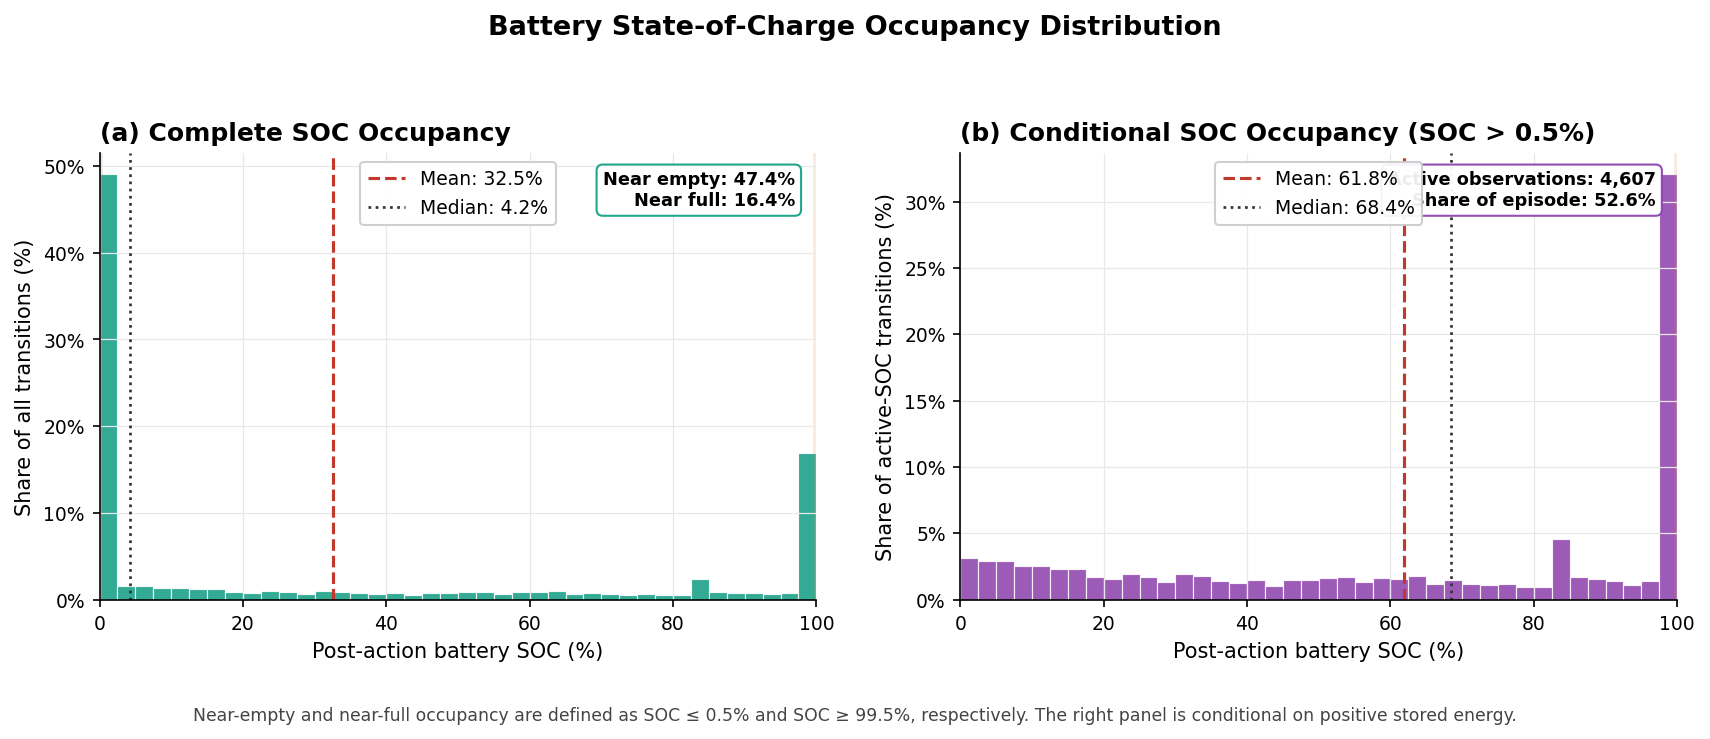

,soc_column,number_of_transitions,mean_soc_percent,median_soc_percent,minimum_soc_percent,maximum_soc_percent,near_empty_threshold_percent,near_empty_transition_count,near_empty_occupancy_percent,near_full_threshold_percent,near_full_transition_count,near_full_occupancy_percent,active_soc_transition_count,active_soc_occupancy_percent,active_soc_mean_percent,active_soc_median_percent
0,post_action_soc_percent,8759,32.518885,4.179883,0.0,100.0,0.5,4152,47.402672,99.5,1438,16.417399,4607,52.597328,61.824538,68.400935


SOC-distribution summary saved to:
D:\CityLearn\12_Transfer learning\0_28July_IF_U\6_standrad\results\2_Building_2\analysis_tables\plot06_soc_occupancy_distribution_summary.csv


In [33]:
# =============================================================================
# Plot 6: Battery SOC occupancy distribution
# =============================================================================

# This figure describes the distribution of post-action battery SOC
# over one complete evaluation episode.
#
# The left panel includes all transitions.
# The right panel is conditional on SOC exceeding the explicitly
# defined near-empty tolerance.
#
# This is a single-run diagnostic and does not represent
# multi-seed uncertainty.

SOC_COLUMN = 'post_action_soc_percent'

# Values at or below this tolerance are classified as near-empty.
SOC_EMPTY_TOLERANCE_PERCENT = 0.5

# Values at or above this threshold are classified as near-full.
SOC_FULL_TOLERANCE_PERCENT = 99.5

# Forty equal-width bins over the physical 0% to 100% SOC range.
SOC_BIN_EDGES = np.linspace(
    0.0,
    100.0,
    41,
)


# =============================================================================
# Validate the SOC data
# =============================================================================

if SOC_COLUMN not in df.columns:
    raise KeyError(
        f'The SOC-distribution plot requires the column '
        f'"{SOC_COLUMN}", but the column is unavailable.'
    )


soc_all = df[
    SOC_COLUMN
].astype(float)


if soc_all.empty:
    raise ValueError(
        'The SOC series contains no observations.'
    )


if not np.isfinite(
    soc_all.to_numpy()
).all():
    raise ValueError(
        f'The column "{SOC_COLUMN}" contains NaN or infinite values.'
    )


# Allow a small tolerance for floating-point representation.
if (
    soc_all.min() < -1e-8
    or soc_all.max() > 100.0 + 1e-8
):
    raise ValueError(
        'Post-action SOC contains values outside the expected '
        '0% to 100% physical range.\n'
        f'Observed range: {soc_all.min():.6f}% to '
        f'{soc_all.max():.6f}%.'
    )


if not (
    0.0
    <= SOC_EMPTY_TOLERANCE_PERCENT
    < SOC_FULL_TOLERANCE_PERCENT
    <= 100.0
):
    raise ValueError(
        'The SOC empty and full thresholds are invalid.'
    )


# =============================================================================
# Construct SOC subsets
# =============================================================================

near_empty_mask = (
    soc_all
    <= SOC_EMPTY_TOLERANCE_PERCENT
)

near_full_mask = (
    soc_all
    >= SOC_FULL_TOLERANCE_PERCENT
)

soc_active = soc_all.loc[
    ~near_empty_mask
]


if soc_active.empty:
    raise ValueError(
        'No SOC observations exceed the near-empty tolerance of '
        f'{SOC_EMPTY_TOLERANCE_PERCENT:.1f}%.'
    )


# =============================================================================
# Calculate descriptive SOC statistics
# =============================================================================

soc_mean = float(
    soc_all.mean()
)

soc_median = float(
    soc_all.median()
)

soc_active_mean = float(
    soc_active.mean()
)

soc_active_median = float(
    soc_active.median()
)

near_empty_percentage = (
    100.0
    * float(
        near_empty_mask.mean()
    )
)

near_full_percentage = (
    100.0
    * float(
        near_full_mask.mean()
    )
)

active_soc_percentage = (
    100.0
    * len(soc_active)
    / len(soc_all)
)


# =============================================================================
# Create histogram weights as percentage of observations
# =============================================================================

all_soc_weights = np.full(
    shape=len(soc_all),
    fill_value=100.0 / len(soc_all),
)

active_soc_weights = np.full(
    shape=len(soc_active),
    fill_value=100.0 / len(soc_active),
)


# =============================================================================
# Create the figure
# =============================================================================

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(11.5, 4.8),
    sharex=True,
)


# =============================================================================
# Panel (a): Complete SOC distribution
# =============================================================================

axes[0].hist(
    soc_all,
    bins=SOC_BIN_EDGES,
    weights=all_soc_weights,
    color=TEAL,
    edgecolor='white',
    linewidth=0.55,
    alpha=0.88,
)

axes[0].axvline(
    soc_mean,
    color=RED,
    linewidth=1.5,
    linestyle='--',
    label=f'Mean: {soc_mean:.1f}%',
)

axes[0].axvline(
    soc_median,
    color='#333333',
    linewidth=1.3,
    linestyle=':',
    label=f'Median: {soc_median:.1f}%',
)

axes[0].axvspan(
    0.0,
    SOC_EMPTY_TOLERANCE_PERCENT,
    color=GRAY,
    alpha=0.15,
    linewidth=0.0,
)

axes[0].axvspan(
    SOC_FULL_TOLERANCE_PERCENT,
    100.0,
    color=ORANGE,
    alpha=0.15,
    linewidth=0.0,
)

axes[0].set_xlabel(
    'Post-action battery SOC (%)'
)

axes[0].set_ylabel(
    'Share of all transitions (%)'
)

axes[0].set_title(
    '(a) Complete SOC Occupancy',
    loc='left',
)

axes[0].legend(
    loc='upper center',
    frameon=True,
    framealpha=0.93,
    facecolor='white',
    edgecolor='#CCCCCC',
)


# Add occupancy statistics.
axes[0].text(
    0.97,
    0.96,
    (
        f'Near empty: {near_empty_percentage:.1f}%\n'
        f'Near full: {near_full_percentage:.1f}%'
    ),
    transform=axes[0].transAxes,
    horizontalalignment='right',
    verticalalignment='top',
    fontsize=8.5,
    fontweight='bold',
    bbox={
        'boxstyle': 'round,pad=0.35',
        'facecolor': 'white',
        'edgecolor': TEAL,
        'linewidth': 1.0,
        'alpha': 0.95,
    },
)


# =============================================================================
# Panel (b): SOC distribution conditional on active stored energy
# =============================================================================

axes[1].hist(
    soc_active,
    bins=SOC_BIN_EDGES,
    weights=active_soc_weights,
    color=PURPLE,
    edgecolor='white',
    linewidth=0.55,
    alpha=0.88,
)

axes[1].axvline(
    soc_active_mean,
    color=RED,
    linewidth=1.5,
    linestyle='--',
    label=f'Mean: {soc_active_mean:.1f}%',
)

axes[1].axvline(
    soc_active_median,
    color='#333333',
    linewidth=1.3,
    linestyle=':',
    label=f'Median: {soc_active_median:.1f}%',
)

axes[1].axvspan(
    SOC_FULL_TOLERANCE_PERCENT,
    100.0,
    color=ORANGE,
    alpha=0.15,
    linewidth=0.0,
)

axes[1].set_xlabel(
    'Post-action battery SOC (%)'
)

axes[1].set_ylabel(
    'Share of active-SOC transitions (%)'
)

axes[1].set_title(
    (
        '(b) Conditional SOC Occupancy '
        f'(SOC > {SOC_EMPTY_TOLERANCE_PERCENT:.1f}%)'
    ),
    loc='left',
)

axes[1].legend(
    loc='upper center',
    frameon=True,
    framealpha=0.93,
    facecolor='white',
    edgecolor='#CCCCCC',
)


axes[1].text(
    0.97,
    0.96,
    (
        f'Active observations: {len(soc_active):,}\n'
        f'Share of episode: {active_soc_percentage:.1f}%'
    ),
    transform=axes[1].transAxes,
    horizontalalignment='right',
    verticalalignment='top',
    fontsize=8.5,
    fontweight='bold',
    bbox={
        'boxstyle': 'round,pad=0.35',
        'facecolor': 'white',
        'edgecolor': PURPLE,
        'linewidth': 1.0,
        'alpha': 0.95,
    },
)


# =============================================================================
# Shared axis formatting
# =============================================================================

for axis in axes:

    axis.set_xlim(
        0.0,
        100.0,
    )

    axis.xaxis.set_major_locator(
        ticker.MaxNLocator(
            nbins=6,
        )
    )

    axis.yaxis.set_major_formatter(
        ticker.PercentFormatter(
            xmax=100.0,
            decimals=0,
        )
    )


# =============================================================================
# Figure title and explanatory note
# =============================================================================

fig.suptitle(
    'Battery State-of-Charge Occupancy Distribution',
    fontsize=13,
    fontweight='bold',
    y=0.99,
)

fig.text(
    0.5,
    0.01,
    (
        'Near-empty and near-full occupancy are defined as '
        f'SOC ≤ {SOC_EMPTY_TOLERANCE_PERCENT:.1f}% and '
        f'SOC ≥ {SOC_FULL_TOLERANCE_PERCENT:.1f}%, respectively. '
        'The right panel is conditional on positive stored energy.'
    ),
    horizontalalignment='center',
    fontsize=8.3,
    color='#444444',
)

fig.tight_layout(
    rect=[
        0.0,
        0.06,
        1.0,
        0.94,
    ],
    w_pad=2.0,
)


# =============================================================================
# Save the figure
# =============================================================================

save_figure(
    fig,
    'plot06_soc_occupancy_distribution',
)


# =============================================================================
# Save the numerical summary
# =============================================================================

plot06_summary = pd.DataFrame([{
    'soc_column': SOC_COLUMN,
    'number_of_transitions': len(soc_all),
    'mean_soc_percent': soc_mean,
    'median_soc_percent': soc_median,
    'minimum_soc_percent': float(
        soc_all.min()
    ),
    'maximum_soc_percent': float(
        soc_all.max()
    ),
    'near_empty_threshold_percent':
        SOC_EMPTY_TOLERANCE_PERCENT,
    'near_empty_transition_count': int(
        near_empty_mask.sum()
    ),
    'near_empty_occupancy_percent':
        near_empty_percentage,
    'near_full_threshold_percent':
        SOC_FULL_TOLERANCE_PERCENT,
    'near_full_transition_count': int(
        near_full_mask.sum()
    ),
    'near_full_occupancy_percent':
        near_full_percentage,
    'active_soc_transition_count':
        len(soc_active),
    'active_soc_occupancy_percent':
        active_soc_percentage,
    'active_soc_mean_percent':
        soc_active_mean,
    'active_soc_median_percent':
        soc_active_median,
}])


plot06_summary_path = (
    TABLES_DIR
    / 'plot06_soc_occupancy_distribution_summary.csv'
)

plot06_summary.to_csv(
    plot06_summary_path,
    index=False,
)

display(
    plot06_summary
)

print(
    'SOC-distribution summary saved to:\n'
    f'{plot06_summary_path}'
)

Saved: D:\CityLearn\12_Transfer learning\0_28July_IF_U\6_standrad\results\2_Building_2\analysis_figures\plot07_battery_charge_discharge_behaviour.png
Saved: D:\CityLearn\12_Transfer learning\0_28July_IF_U\6_standrad\results\2_Building_2\analysis_figures\plot07_battery_charge_discharge_behaviour.pdf


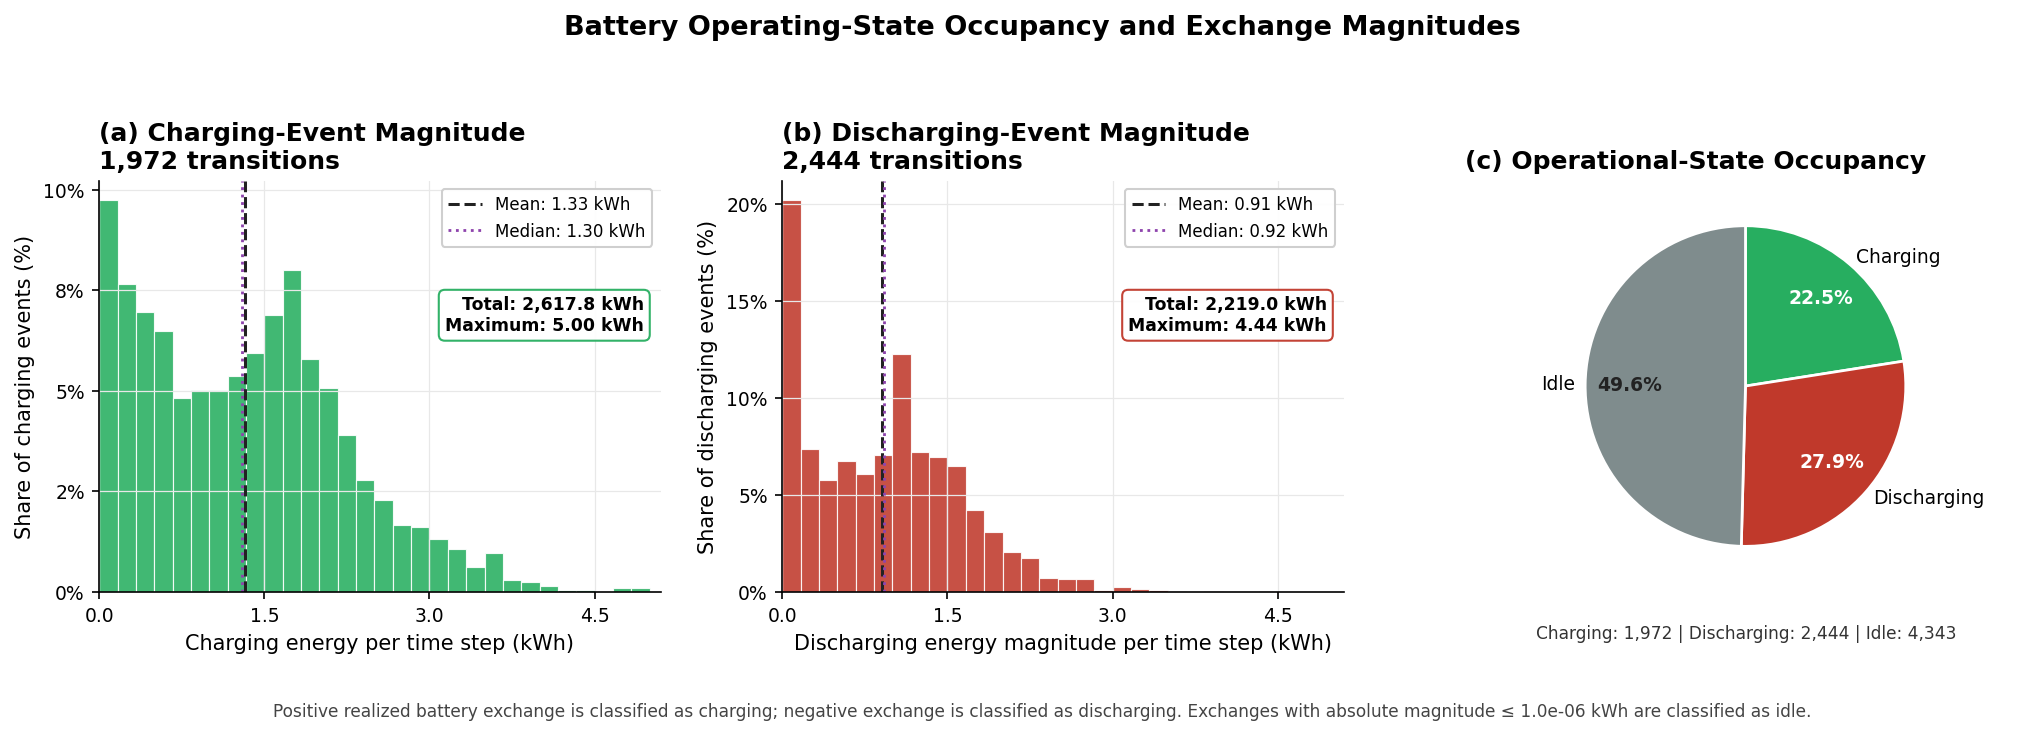

,battery_column,idle_tolerance_kwh,number_of_transitions,charging_transition_count,charging_transition_percent,discharging_transition_count,discharging_transition_percent,idle_transition_count,idle_transition_percent,total_charging_energy_kwh,total_discharge_magnitude_kwh,mean_charging_event_kwh,median_charging_event_kwh,maximum_charging_event_kwh,mean_discharge_event_kwh,median_discharge_event_kwh,maximum_discharge_event_kwh,active_direction_reversals
0,battery_consumption,0.000001,8759,1972,22.513986,2444,27.902729,4343,49.583286,2617.770023,2219.00971,1.32747,1.296146,5.0,0.907942,0.920545,4.438515,1283


Battery-operation summary saved to:
D:\CityLearn\12_Transfer learning\0_28July_IF_U\6_standrad\results\2_Building_2\analysis_tables\plot07_battery_charge_discharge_behaviour_summary.csv


In [34]:
# =============================================================================
# Plot 7: Battery charging and discharging behaviour
# =============================================================================

# This figure characterizes realized battery operation over one complete
# evaluation episode.
#
# Panels (a) and (b) show the magnitudes of active charging and
# discharging events. Panel (c) shows the percentage of transitions
# classified as charging, discharging, or idle.
#
# This is a single-run behavioural diagnostic and does not represent
# multi-seed uncertainty or battery-degradation performance.


# =============================================================================
# Configuration
# =============================================================================

BATTERY_COLUMN = 'battery_consumption'

# Realized battery exchanges with absolute magnitude less than or equal
# to this tolerance are classified as operationally idle.
BATTERY_IDLE_TOLERANCE_KWH = 1e-6

# Number of common histogram intervals.
NUMBER_OF_BINS = 30

# State colors
CHARGING_COLOR = GREEN
DISCHARGING_COLOR = RED
IDLE_COLOR = GRAY


# =============================================================================
# Validate the battery-consumption column
# =============================================================================

if BATTERY_COLUMN not in df.columns:
    raise KeyError(
        'The charging and discharging plot requires the column '
        f'"{BATTERY_COLUMN}", but the column is unavailable.'
    )


battery_exchange = df[
    BATTERY_COLUMN
].astype(float)


if battery_exchange.empty:
    raise ValueError(
        'The battery-consumption series contains no transitions.'
    )


if not np.isfinite(
    battery_exchange.to_numpy()
).all():
    raise ValueError(
        f'The column "{BATTERY_COLUMN}" contains NaN or '
        'infinite values.'
    )


if BATTERY_IDLE_TOLERANCE_KWH < 0.0:
    raise ValueError(
        'BATTERY_IDLE_TOLERANCE_KWH cannot be negative.'
    )


# =============================================================================
# Classify operational states using the numerical deadband
# =============================================================================

charging_mask = (
    battery_exchange
    > BATTERY_IDLE_TOLERANCE_KWH
)

discharging_mask = (
    battery_exchange
    < -BATTERY_IDLE_TOLERANCE_KWH
)

idle_mask = (
    battery_exchange.abs()
    <= BATTERY_IDLE_TOLERANCE_KWH
)


# Verify that each transition belongs to exactly one state.
state_membership_count = (
    charging_mask.astype(int)
    + discharging_mask.astype(int)
    + idle_mask.astype(int)
)

if not (
    state_membership_count == 1
).all():
    raise ValueError(
        'Battery operating-state classification failed. '
        'At least one transition was assigned to zero or '
        'multiple operational states.'
    )


# =============================================================================
# Extract charging and discharging magnitudes
# =============================================================================

charging_events = battery_exchange.loc[
    charging_mask
].copy()

# Convert negative discharge exchanges to positive magnitudes.
discharging_magnitudes = (
    -battery_exchange.loc[
        discharging_mask
    ]
).copy()


if charging_events.empty:
    raise ValueError(
        'No charging events were identified using the selected '
        f'idle tolerance of {BATTERY_IDLE_TOLERANCE_KWH:.1e} kWh.'
    )


if discharging_magnitudes.empty:
    raise ValueError(
        'No discharging events were identified using the selected '
        f'idle tolerance of {BATTERY_IDLE_TOLERANCE_KWH:.1e} kWh.'
    )


# =============================================================================
# Calculate transition counts and occupancy percentages
# =============================================================================

number_of_transitions = len(
    battery_exchange
)

charging_count = int(
    charging_mask.sum()
)

discharging_count = int(
    discharging_mask.sum()
)

idle_count = int(
    idle_mask.sum()
)


charging_percentage = (
    100.0
    * charging_count
    / number_of_transitions
)

discharging_percentage = (
    100.0
    * discharging_count
    / number_of_transitions
)

idle_percentage = (
    100.0
    * idle_count
    / number_of_transitions
)


# Confirm that the percentages sum to 100%.
occupancy_percentage_sum = (
    charging_percentage
    + discharging_percentage
    + idle_percentage
)

if not np.isclose(
    occupancy_percentage_sum,
    100.0,
    atol=1e-8,
    rtol=0.0,
):
    raise ValueError(
        'Battery operating-state percentages do not sum to 100%.'
    )


# =============================================================================
# Calculate energy and event-magnitude statistics
# =============================================================================

total_charging_energy = float(
    charging_events.sum()
)

total_discharging_magnitude = float(
    discharging_magnitudes.sum()
)

mean_charging_magnitude = float(
    charging_events.mean()
)

median_charging_magnitude = float(
    charging_events.median()
)

maximum_charging_magnitude = float(
    charging_events.max()
)

mean_discharging_magnitude = float(
    discharging_magnitudes.mean()
)

median_discharging_magnitude = float(
    discharging_magnitudes.median()
)

maximum_discharging_magnitude = float(
    discharging_magnitudes.max()
)


# =============================================================================
# Calculate active charge-discharge direction reversals
# =============================================================================

# Map every transition to:
#  1 = charging
#  0 = idle
# -1 = discharging

operating_state = np.zeros(
    number_of_transitions,
    dtype=int,
)

operating_state[
    charging_mask.to_numpy()
] = 1

operating_state[
    discharging_mask.to_numpy()
] = -1


# Remove idle observations before calculating direction reversals.
# Consequently, charging -> idle -> discharging is counted as one
# active-state reversal rather than two separate sign changes.
active_operating_state = operating_state[
    operating_state != 0
]

if len(active_operating_state) >= 2:

    active_direction_reversals = int(
        np.sum(
            active_operating_state[1:]
            != active_operating_state[:-1]
        )
    )

else:

    active_direction_reversals = 0


# =============================================================================
# Construct common histogram bins
# =============================================================================

maximum_event_magnitude = max(
    maximum_charging_magnitude,
    maximum_discharging_magnitude,
)


if np.isclose(
    maximum_event_magnitude,
    0.0,
    atol=1e-12,
):
    raise ValueError(
        'The maximum active battery-exchange magnitude is zero.'
    )


common_bin_edges = np.linspace(
    0.0,
    maximum_event_magnitude,
    NUMBER_OF_BINS + 1,
)


# Normalize the histograms to percentage of events.
charging_histogram_weights = np.full(
    shape=len(charging_events),
    fill_value=(
        100.0
        / len(charging_events)
    ),
)

discharging_histogram_weights = np.full(
    shape=len(discharging_magnitudes),
    fill_value=(
        100.0
        / len(discharging_magnitudes)
    ),
)


# =============================================================================
# Create the figure
# =============================================================================

fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(14.0, 4.8),
)


# =============================================================================
# Panel (a): Charging-event magnitude distribution
# =============================================================================

axes[0].hist(
    charging_events,
    bins=common_bin_edges,
    weights=charging_histogram_weights,
    color=CHARGING_COLOR,
    edgecolor='white',
    linewidth=0.55,
    alpha=0.88,
)

axes[0].axvline(
    mean_charging_magnitude,
    color='#222222',
    linewidth=1.45,
    linestyle='--',
    label=(
        f'Mean: '
        f'{mean_charging_magnitude:.2f} kWh'
    ),
)

axes[0].axvline(
    median_charging_magnitude,
    color=PURPLE,
    linewidth=1.35,
    linestyle=':',
    label=(
        f'Median: '
        f'{median_charging_magnitude:.2f} kWh'
    ),
)

axes[0].set_xlabel(
    'Charging energy per time step (kWh)'
)

axes[0].set_ylabel(
    'Share of charging events (%)'
)

axes[0].set_title(
    (
        '(a) Charging-Event Magnitude\n'
        f'{charging_count:,} transitions'
    ),
    loc='left',
)

axes[0].legend(
    loc='upper right',
    frameon=True,
    framealpha=0.93,
    facecolor='white',
    edgecolor='#CCCCCC',
    fontsize=8,
)


axes[0].text(
    0.97,
    0.72,
    (
        f'Total: {total_charging_energy:,.1f} kWh\n'
        f'Maximum: {maximum_charging_magnitude:.2f} kWh'
    ),
    transform=axes[0].transAxes,
    horizontalalignment='right',
    verticalalignment='top',
    fontsize=8.3,
    fontweight='bold',
    bbox={
        'boxstyle': 'round,pad=0.35',
        'facecolor': 'white',
        'edgecolor': CHARGING_COLOR,
        'linewidth': 1.0,
        'alpha': 0.95,
    },
)


# =============================================================================
# Panel (b): Discharging-event magnitude distribution
# =============================================================================

axes[1].hist(
    discharging_magnitudes,
    bins=common_bin_edges,
    weights=discharging_histogram_weights,
    color=DISCHARGING_COLOR,
    edgecolor='white',
    linewidth=0.55,
    alpha=0.88,
)

axes[1].axvline(
    mean_discharging_magnitude,
    color='#222222',
    linewidth=1.45,
    linestyle='--',
    label=(
        f'Mean: '
        f'{mean_discharging_magnitude:.2f} kWh'
    ),
)

axes[1].axvline(
    median_discharging_magnitude,
    color=PURPLE,
    linewidth=1.35,
    linestyle=':',
    label=(
        f'Median: '
        f'{median_discharging_magnitude:.2f} kWh'
    ),
)

axes[1].set_xlabel(
    'Discharging energy magnitude per time step (kWh)'
)

axes[1].set_ylabel(
    'Share of discharging events (%)'
)

axes[1].set_title(
    (
        '(b) Discharging-Event Magnitude\n'
        f'{discharging_count:,} transitions'
    ),
    loc='left',
)

axes[1].legend(
    loc='upper right',
    frameon=True,
    framealpha=0.93,
    facecolor='white',
    edgecolor='#CCCCCC',
    fontsize=8,
)


axes[1].text(
    0.97,
    0.72,
    (
        f'Total: {total_discharging_magnitude:,.1f} kWh\n'
        f'Maximum: {maximum_discharging_magnitude:.2f} kWh'
    ),
    transform=axes[1].transAxes,
    horizontalalignment='right',
    verticalalignment='top',
    fontsize=8.3,
    fontweight='bold',
    bbox={
        'boxstyle': 'round,pad=0.35',
        'facecolor': 'white',
        'edgecolor': DISCHARGING_COLOR,
        'linewidth': 1.0,
        'alpha': 0.95,
    },
)


# =============================================================================
# Panel (c): Operational-state occupancy pie chart
# =============================================================================

operating_percentages = [
    charging_percentage,
    discharging_percentage,
    idle_percentage,
]

operating_labels = [
    'Charging',
    'Discharging',
    'Idle',
]

operating_colors = [
    CHARGING_COLOR,
    DISCHARGING_COLOR,
    IDLE_COLOR,
]


wedges, pie_texts, percentage_texts = axes[2].pie(
    operating_percentages,
    labels=operating_labels,
    colors=operating_colors,
    autopct='%1.1f%%',
    startangle=90,
    counterclock=False,
    pctdistance=0.72,
    labeldistance=1.06,
    wedgeprops={
        'edgecolor': 'white',
        'linewidth': 1.3,
    },
    textprops={
        'fontsize': 9,
    },
)


# Improve the readability of percentage labels.
for percentage_text in percentage_texts:

    percentage_text.set_fontweight(
        'bold'
    )

    percentage_text.set_color(
        'white'
    )


# Use dark text if the idle segment is too light for white text.
if len(percentage_texts) >= 3:

    percentage_texts[2].set_color(
        '#222222'
    )


axes[2].set_title(
    '(c) Operational-State Occupancy',
    loc='left',
)


# Add numerical counts below the pie chart.
axes[2].text(
    0.5,
    -0.08,
    (
        f'Charging: {charging_count:,} | '
        f'Discharging: {discharging_count:,} | '
        f'Idle: {idle_count:,}'
    ),
    transform=axes[2].transAxes,
    horizontalalignment='center',
    verticalalignment='top',
    fontsize=8.2,
    color='#333333',
)


# Keep the pie chart circular.
axes[2].axis(
    'equal'
)


# =============================================================================
# Shared histogram formatting
# =============================================================================

for axis in axes[:2]:

    axis.set_xlim(
        0.0,
        maximum_event_magnitude
        * 1.02,
    )

    axis.xaxis.set_major_locator(
        ticker.MaxNLocator(
            nbins=5,
        )
    )

    axis.yaxis.set_major_locator(
        ticker.MaxNLocator(
            nbins=5,
        )
    )

    axis.yaxis.set_major_formatter(
        ticker.PercentFormatter(
            xmax=100.0,
            decimals=0,
        )
    )


# =============================================================================
# Figure title and methodological note
# =============================================================================

fig.suptitle(
    'Battery Operating-State Occupancy and Exchange Magnitudes',
    fontsize=13,
    fontweight='bold',
    y=0.99,
)


fig.text(
    0.5,
    0.01,
    (
        'Positive realized battery exchange is classified as charging; '
        'negative exchange is classified as discharging. Exchanges with '
        f'absolute magnitude ≤ {BATTERY_IDLE_TOLERANCE_KWH:.1e} kWh '
        'are classified as idle.'
    ),
    horizontalalignment='center',
    verticalalignment='bottom',
    fontsize=8.2,
    color='#444444',
)


fig.tight_layout(
    rect=[
        0.0,
        0.07,
        1.0,
        0.94,
    ],
    w_pad=1.8,
)


# =============================================================================
# Save the figure
# =============================================================================

save_figure(
    fig,
    'plot07_battery_charge_discharge_behaviour',
)


# =============================================================================
# Create and save the numerical summary
# =============================================================================

plot07_summary = pd.DataFrame([{
    'battery_column': BATTERY_COLUMN,
    'idle_tolerance_kwh':
        BATTERY_IDLE_TOLERANCE_KWH,
    'number_of_transitions':
        number_of_transitions,

    'charging_transition_count':
        charging_count,
    'charging_transition_percent':
        charging_percentage,

    'discharging_transition_count':
        discharging_count,
    'discharging_transition_percent':
        discharging_percentage,

    'idle_transition_count':
        idle_count,
    'idle_transition_percent':
        idle_percentage,

    'total_charging_energy_kwh':
        total_charging_energy,
    'total_discharge_magnitude_kwh':
        total_discharging_magnitude,

    'mean_charging_event_kwh':
        mean_charging_magnitude,
    'median_charging_event_kwh':
        median_charging_magnitude,
    'maximum_charging_event_kwh':
        maximum_charging_magnitude,

    'mean_discharge_event_kwh':
        mean_discharging_magnitude,
    'median_discharge_event_kwh':
        median_discharging_magnitude,
    'maximum_discharge_event_kwh':
        maximum_discharging_magnitude,

    'active_direction_reversals':
        active_direction_reversals,
}])


plot07_summary_path = (
    TABLES_DIR
    / 'plot07_battery_charge_discharge_behaviour_summary.csv'
)

plot07_summary.to_csv(
    plot07_summary_path,
    index=False,
)

display(
    plot07_summary
)

print(
    'Battery-operation summary saved to:\n'
    f'{plot07_summary_path}'
)

Partial sequential weeks excluded from Panel (b): [53]
Saved: D:\CityLearn\12_Transfer learning\0_28July_IF_U\6_standrad\results\2_Building_2\analysis_figures\plot10_pv_energy_allocation.png
Saved: D:\CityLearn\12_Transfer learning\0_28July_IF_U\6_standrad\results\2_Building_2\analysis_figures\plot10_pv_energy_allocation.pdf


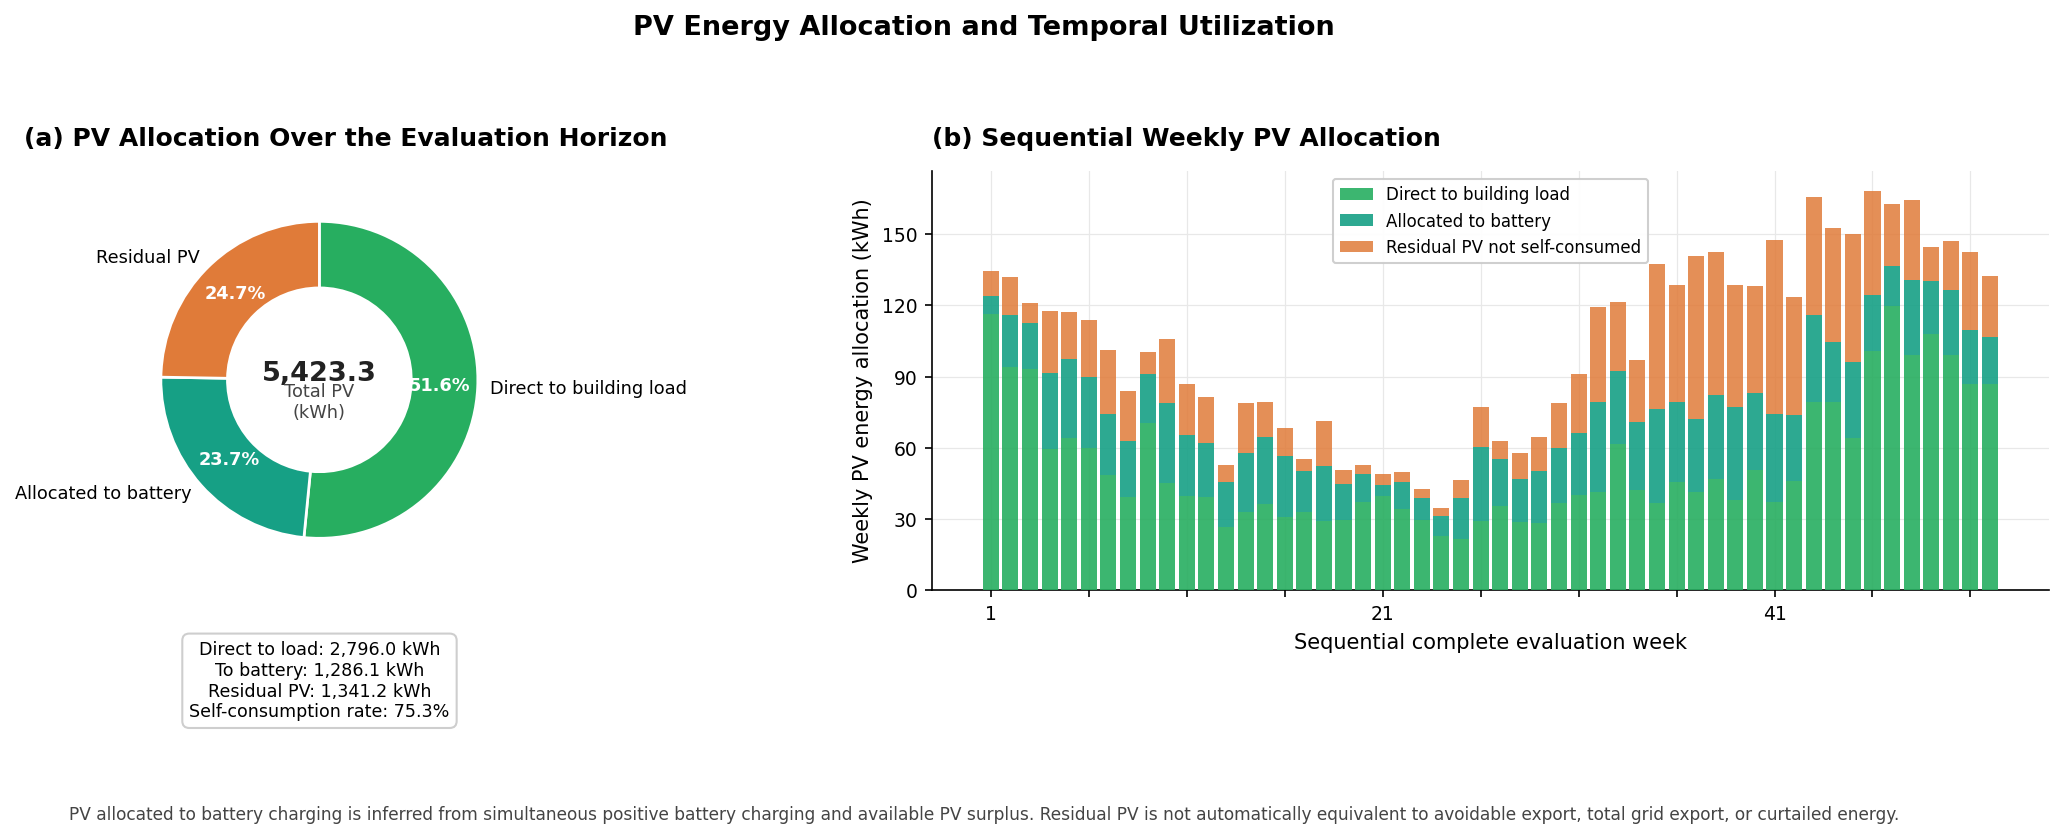

,number_of_transitions,total_pv_generation_kwh,pv_to_load_kwh,pv_to_load_percent,pv_to_battery_kwh,pv_to_battery_percent,pv_self_consumed_kwh,pv_self_consumption_rate_percent,residual_pv_kwh,residual_pv_percent,minimum_raw_residual_kwh,number_of_complete_weeks,number_of_partial_weeks,partial_week_numbers
0,8759,5423.290034,2795.965379,51.554782,1286.122232,23.714797,4082.08761,75.26958,1341.202423,24.73042,-4.440892e-16,52,1,53


,evaluation_week,pv_generation,pv_to_load,pv_to_battery,pv_self_consumed,pv_residual,pv_self_consumption_rate_percent
0,1,134.520012,116.382429,7.661972,124.044401,10.475611,92.212601
1,2,131.803850,94.113000,21.720007,115.833007,15.970843,87.882871
2,3,120.854459,93.397113,19.326456,112.723569,8.130890,93.272164
3,4,117.448658,59.418692,32.296565,91.715256,25.733402,78.089659
4,5,117.342871,64.252088,33.046968,97.299056,20.043815,82.918591


PV-allocation summary saved to:
D:\CityLearn\12_Transfer learning\0_28July_IF_U\6_standrad\results\2_Building_2\analysis_tables\plot10_pv_energy_allocation_summary.csv
Weekly PV-allocation table saved to:
D:\CityLearn\12_Transfer learning\0_28July_IF_U\6_standrad\results\2_Building_2\analysis_tables\plot10_weekly_pv_energy_allocation.csv


In [35]:
# =============================================================================
# Plot 10: PV energy allocation and weekly utilization
# =============================================================================

# This figure decomposes PV generation into:
#
# 1. PV supplied directly to the building load.
# 2. PV allocated to battery charging during simultaneous PV surplus.
# 3. Residual PV not self-consumed.
#
# The residual PV component is an allocation residual. It must not be
# interpreted automatically as avoidable export, curtailment, or total
# grid export.
#
# Panel (a) reports the allocation over the complete evaluation horizon.
# Panel (b) reports the same allocation for complete sequential weeks.
#
# This is a single-run diagnostic and does not represent multi-seed
# uncertainty or statistical significance.


# =============================================================================
# Configuration
# =============================================================================

HOURS_PER_DAY = 24
DAYS_PER_WEEK = 7
HOURS_PER_WEEK = (
    HOURS_PER_DAY
    * DAYS_PER_WEEK
)

PV_IDENTITY_ATOL = 1e-8
PV_IDENTITY_RTOL = 1e-6

# Colors used consistently across both panels.
PV_TO_LOAD_COLOR = GREEN
PV_TO_BATTERY_COLOR = TEAL
PV_RESIDUAL_COLOR = ORANGE


# =============================================================================
# Validate required columns
# =============================================================================

pv_required_columns = [
    'transition',
    'pv_generation',
    'pv_to_load',
    'pv_to_battery',
    'pv_self_consumed',
]

pv_missing_columns = [
    column
    for column in pv_required_columns
    if column not in df.columns
]

if pv_missing_columns:
    raise KeyError(
        'The PV-allocation figure cannot be generated because '
        'the following columns are missing:\n'
        f'{pv_missing_columns}'
    )


# =============================================================================
# Validate numerical values
# =============================================================================

pv_non_finite_columns = []

for column in pv_required_columns:

    column_values = df[column].to_numpy(
        dtype=float
    )

    if not np.isfinite(
        column_values
    ).all():
        pv_non_finite_columns.append(
            column
        )

if pv_non_finite_columns:
    raise ValueError(
        'NaN or infinite values were detected in the following '
        'PV-allocation columns:\n'
        f'{pv_non_finite_columns}'
    )


# =============================================================================
# Copy only required analysis data
# =============================================================================

pv_df = df[
    pv_required_columns
].copy()


# =============================================================================
# Check non-negativity
# =============================================================================

pv_nonnegative_columns = [
    'pv_generation',
    'pv_to_load',
    'pv_to_battery',
    'pv_self_consumed',
]

negative_value_report = {}

for column in pv_nonnegative_columns:

    substantial_negative_mask = (
        pv_df[column]
        < -PV_IDENTITY_ATOL
    )

    negative_count = int(
        substantial_negative_mask.sum()
    )

    if negative_count > 0:
        negative_value_report[column] = (
            negative_count
        )

if negative_value_report:
    raise ValueError(
        'Substantial negative values were detected in variables '
        'that should be nonnegative:\n'
        f'{negative_value_report}'
    )


# Set only negligible floating-point negatives to zero.
for column in pv_nonnegative_columns:

    near_zero_negative_mask = (
        (pv_df[column] < 0.0)
        & (
            pv_df[column]
            >= -PV_IDENTITY_ATOL
        )
    )

    pv_df.loc[
        near_zero_negative_mask,
        column,
    ] = 0.0


# =============================================================================
# Validate the PV self-consumption identity
# =============================================================================

expected_pv_self_consumed = (
    pv_df['pv_to_load']
    + pv_df['pv_to_battery']
)

pv_self_consumption_identity_mask = np.isclose(
    pv_df['pv_self_consumed'],
    expected_pv_self_consumed,
    atol=PV_IDENTITY_ATOL,
    rtol=PV_IDENTITY_RTOL,
)

if not pv_self_consumption_identity_mask.all():

    invalid_identity_count = int(
        (
            ~pv_self_consumption_identity_mask
        ).sum()
    )

    maximum_identity_error = float(
        np.max(
            np.abs(
                pv_df['pv_self_consumed']
                - expected_pv_self_consumed
            )
        )
    )

    raise ValueError(
        'The PV self-consumption identity failed.\n'
        f'Invalid transitions: {invalid_identity_count}\n'
        f'Maximum absolute error: '
        f'{maximum_identity_error:.10f} kWh'
    )


# =============================================================================
# Check that self-consumed PV does not exceed generated PV
# =============================================================================

pv_exceedance = (
    pv_df['pv_self_consumed']
    - pv_df['pv_generation']
)

substantial_exceedance_mask = (
    pv_exceedance
    > PV_IDENTITY_ATOL
)

if substantial_exceedance_mask.any():

    exceedance_count = int(
        substantial_exceedance_mask.sum()
    )

    maximum_exceedance = float(
        pv_exceedance.max()
    )

    raise ValueError(
        'PV self-consumption exceeds PV generation at one or '
        'more transitions.\n'
        f'Invalid transitions: {exceedance_count}\n'
        f'Maximum exceedance: '
        f'{maximum_exceedance:.10f} kWh'
    )


# =============================================================================
# Calculate residual PV before applying numerical clipping
# =============================================================================

pv_df['pv_residual_raw'] = (
    pv_df['pv_generation']
    - pv_df['pv_self_consumed']
)

minimum_raw_residual = float(
    pv_df['pv_residual_raw'].min()
)

if minimum_raw_residual < -PV_IDENTITY_ATOL:
    raise ValueError(
        'The raw residual PV contains a substantial negative '
        'value, indicating an allocation inconsistency.\n'
        f'Minimum raw residual: '
        f'{minimum_raw_residual:.10f} kWh'
    )


# Clip only negligible negative values caused by floating-point arithmetic.
pv_df['pv_residual'] = (
    pv_df['pv_residual_raw']
    .clip(
        lower=0.0
    )
)


# =============================================================================
# Validate complete transition-level PV allocation
# =============================================================================

reconstructed_pv_generation = (
    pv_df['pv_to_load']
    + pv_df['pv_to_battery']
    + pv_df['pv_residual']
)

pv_allocation_identity_mask = np.isclose(
    pv_df['pv_generation'],
    reconstructed_pv_generation,
    atol=PV_IDENTITY_ATOL,
    rtol=PV_IDENTITY_RTOL,
)

if not pv_allocation_identity_mask.all():

    invalid_allocation_count = int(
        (
            ~pv_allocation_identity_mask
        ).sum()
    )

    maximum_allocation_error = float(
        np.max(
            np.abs(
                pv_df['pv_generation']
                - reconstructed_pv_generation
            )
        )
    )

    raise ValueError(
        'The complete PV-allocation identity failed.\n'
        f'Invalid transitions: {invalid_allocation_count}\n'
        f'Maximum absolute error: '
        f'{maximum_allocation_error:.10f} kWh'
    )


# =============================================================================
# Calculate evaluation-horizon totals
# =============================================================================

total_pv_generation = float(
    pv_df['pv_generation'].sum()
)

total_pv_to_load = float(
    pv_df['pv_to_load'].sum()
)

total_pv_to_battery = float(
    pv_df['pv_to_battery'].sum()
)

total_pv_self_consumed = float(
    pv_df['pv_self_consumed'].sum()
)

total_pv_residual = float(
    pv_df['pv_residual'].sum()
)


if np.isclose(
    total_pv_generation,
    0.0,
    atol=PV_IDENTITY_ATOL,
):
    raise ValueError(
        'Total PV generation is zero. '
        'PV allocation percentages cannot be calculated.'
    )


# =============================================================================
# Calculate allocation percentages
# =============================================================================

pv_to_load_percentage = (
    100.0
    * total_pv_to_load
    / total_pv_generation
)

pv_to_battery_percentage = (
    100.0
    * total_pv_to_battery
    / total_pv_generation
)

pv_residual_percentage = (
    100.0
    * total_pv_residual
    / total_pv_generation
)

pv_self_consumption_rate = (
    100.0
    * total_pv_self_consumed
    / total_pv_generation
)

allocation_percentage_sum = (
    pv_to_load_percentage
    + pv_to_battery_percentage
    + pv_residual_percentage
)

if not np.isclose(
    allocation_percentage_sum,
    100.0,
    atol=1e-6,
    rtol=0.0,
):
    raise ValueError(
        'PV allocation percentages do not sum to 100%.\n'
        f'Observed sum: {allocation_percentage_sum:.8f}%'
    )


# =============================================================================
# Construct sequential week identifiers
# =============================================================================

pv_df['evaluation_week'] = (
    pv_df['transition']
    // HOURS_PER_WEEK
) + 1

weekly_transition_counts = (
    pv_df.groupby(
        'evaluation_week'
    )
    .size()
    .rename(
        'number_of_transitions'
    )
)

complete_week_numbers = (
    weekly_transition_counts.loc[
        weekly_transition_counts
        == HOURS_PER_WEEK
    ]
    .index
    .tolist()
)

partial_week_numbers = (
    weekly_transition_counts.loc[
        weekly_transition_counts
        != HOURS_PER_WEEK
    ]
    .index
    .tolist()
)

if not complete_week_numbers:
    raise ValueError(
        'No complete 168-transition evaluation weeks were found.'
    )

if partial_week_numbers:
    print(
        'Partial sequential weeks excluded from Panel (b):',
        partial_week_numbers,
    )


# =============================================================================
# Aggregate complete sequential weeks
# =============================================================================

weekly_pv_allocation = (
    pv_df.loc[
        pv_df['evaluation_week']
        .isin(
            complete_week_numbers
        )
    ]
    .groupby(
        'evaluation_week',
        as_index=False,
    )[
        [
            'pv_generation',
            'pv_to_load',
            'pv_to_battery',
            'pv_self_consumed',
            'pv_residual',
        ]
    ]
    .sum()
)


weekly_pv_allocation[
    'pv_self_consumption_rate_percent'
] = (
    100.0
    * weekly_pv_allocation[
        'pv_self_consumed'
    ]
    / weekly_pv_allocation[
        'pv_generation'
    ]
)


# =============================================================================
# Validate weekly PV allocation
# =============================================================================

weekly_reconstructed_pv = (
    weekly_pv_allocation[
        'pv_to_load'
    ]
    + weekly_pv_allocation[
        'pv_to_battery'
    ]
    + weekly_pv_allocation[
        'pv_residual'
    ]
)

weekly_identity_mask = np.isclose(
    weekly_pv_allocation[
        'pv_generation'
    ],
    weekly_reconstructed_pv,
    atol=PV_IDENTITY_ATOL,
    rtol=PV_IDENTITY_RTOL,
)

if not weekly_identity_mask.all():
    raise ValueError(
        'The weekly PV-allocation identity failed.'
    )


# =============================================================================
# Create the two-panel figure
# =============================================================================

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(14.5, 5.5),
    gridspec_kw={
        'width_ratios': [
            0.9,
            1.7,
        ],
    },
)


# =============================================================================
# Panel (a): Evaluation-horizon PV allocation donut chart
# =============================================================================

allocation_values = [
    total_pv_to_load,
    total_pv_to_battery,
    total_pv_residual,
]

allocation_labels = [
    'Direct to building load',
    'Allocated to battery',
    'Residual PV',
]

allocation_colors = [
    PV_TO_LOAD_COLOR,
    PV_TO_BATTERY_COLOR,
    PV_RESIDUAL_COLOR,
]


wedges, pie_labels, percentage_labels = axes[0].pie(
    allocation_values,
    labels=allocation_labels,
    colors=allocation_colors,
    autopct='%1.1f%%',
    startangle=90,
    counterclock=False,
    pctdistance=0.76,
    labeldistance=1.08,
    wedgeprops={
        'edgecolor': 'white',
        'linewidth': 1.3,
        'width': 0.42,
    },
    textprops={
        'fontsize': 8.5,
    },
)


# Format percentage text inside the donut.
for percentage_text in percentage_labels:

    percentage_text.set_fontweight(
        'bold'
    )

    percentage_text.set_color(
        'white'
    )


# Add total PV generation in the centre.
axes[0].text(
    0.0,
    0.04,
    f'{total_pv_generation:,.1f}',
    horizontalalignment='center',
    verticalalignment='center',
    fontsize=13,
    fontweight='bold',
    color='#222222',
)

axes[0].text(
    0.0,
    -0.14,
    'Total PV\n(kWh)',
    horizontalalignment='center',
    verticalalignment='center',
    fontsize=8.5,
    color='#444444',
)


axes[0].set_title(
    '(a) PV Allocation Over the Evaluation Horizon',
    loc='left',
    pad=12,
)

axes[0].axis(
    'equal'
)


# Add exact absolute allocation values.
axes[0].text(
    0.50,
    -0.12,
    (
        f'Direct to load: '
        f'{total_pv_to_load:,.1f} kWh\n'
        f'To battery: '
        f'{total_pv_to_battery:,.1f} kWh\n'
        f'Residual PV: '
        f'{total_pv_residual:,.1f} kWh\n'
        f'Self-consumption rate: '
        f'{pv_self_consumption_rate:.1f}%'
    ),
    transform=axes[0].transAxes,
    horizontalalignment='center',
    verticalalignment='top',
    fontsize=8.4,
    bbox={
        'boxstyle': 'round,pad=0.40',
        'facecolor': 'white',
        'edgecolor': '#CCCCCC',
        'linewidth': 1.0,
        'alpha': 0.96,
    },
)


# =============================================================================
# Panel (b): Weekly stacked PV allocation
# =============================================================================

weekly_x = np.arange(
    len(
        weekly_pv_allocation
    )
)

weekly_to_load = weekly_pv_allocation[
    'pv_to_load'
].to_numpy()

weekly_to_battery = weekly_pv_allocation[
    'pv_to_battery'
].to_numpy()

weekly_residual = weekly_pv_allocation[
    'pv_residual'
].to_numpy()


axes[1].bar(
    weekly_x,
    weekly_to_load,
    width=0.82,
    color=PV_TO_LOAD_COLOR,
    alpha=0.90,
    label='Direct to building load',
    zorder=3,
)

axes[1].bar(
    weekly_x,
    weekly_to_battery,
    width=0.82,
    bottom=weekly_to_load,
    color=PV_TO_BATTERY_COLOR,
    alpha=0.90,
    label='Allocated to battery',
    zorder=3,
)

axes[1].bar(
    weekly_x,
    weekly_residual,
    width=0.82,
    bottom=(
        weekly_to_load
        + weekly_to_battery
    ),
    color=PV_RESIDUAL_COLOR,
    alpha=0.85,
    label='Residual PV not self-consumed',
    zorder=3,
)


axes[1].set_xlabel(
    'Sequential complete evaluation week'
)

axes[1].set_ylabel(
    'Weekly PV energy allocation (kWh)'
)

axes[1].set_title(
    '(b) Sequential Weekly PV Allocation',
    loc='left',
    pad=12,
)


axes[1].legend(
    loc='upper center',
    ncol=1,
    frameon=True,
    framealpha=0.94,
    facecolor='white',
    edgecolor='#CCCCCC',
    fontsize=8,
)


# Show a manageable number of weekly labels.
number_of_complete_weeks = len(
    weekly_pv_allocation
)

weekly_tick_step = max(
    1,
    int(
        np.ceil(
            number_of_complete_weeks
            / 13.0
        )
    ),
)

weekly_tick_positions = np.arange(
    0,
    number_of_complete_weeks,
    weekly_tick_step,
)

weekly_tick_labels = (
    weekly_pv_allocation[
        'evaluation_week'
    ]
    .iloc[
        weekly_tick_positions
    ]
    .astype(int)
    .astype(str)
    .tolist()
)


axes[1].set_xticks(
    weekly_tick_positions
)

axes[1].set_xticklabels(
    weekly_tick_labels
)


axes[1].xaxis.set_major_locator(
    ticker.MaxNLocator(
        nbins=13,
        integer=True,
    )
)

axes[1].yaxis.set_major_locator(
    ticker.MaxNLocator(
        nbins=6,
    )
)

axes[1].yaxis.set_major_formatter(
    ticker.StrMethodFormatter(
        '{x:,.0f}'
    )
)


# =============================================================================
# Figure title and explanatory note
# =============================================================================

fig.suptitle(
    'PV Energy Allocation and Temporal Utilization',
    fontsize=13,
    fontweight='bold',
    y=0.99,
)


fig.text(
    0.5,
    0.01,
    (
        'PV allocated to battery charging is inferred from simultaneous '
        'positive battery charging and available PV surplus. Residual PV '
        'is not automatically equivalent to avoidable export, total grid '
        'export, or curtailed energy.'
    ),
    horizontalalignment='center',
    verticalalignment='bottom',
    fontsize=8.2,
    color='#444444',
)


fig.tight_layout(
    rect=[
        0.0,
        0.075,
        1.0,
        0.94,
    ],
    w_pad=2.3,
)


# =============================================================================
# Save the figure
# =============================================================================

save_figure(
    fig,
    'plot10_pv_energy_allocation',
)


# =============================================================================
# Create and save evaluation-horizon summary
# =============================================================================

plot10_summary = pd.DataFrame([{
    'number_of_transitions': len(
        pv_df
    ),
    'total_pv_generation_kwh':
        total_pv_generation,
    'pv_to_load_kwh':
        total_pv_to_load,
    'pv_to_load_percent':
        pv_to_load_percentage,
    'pv_to_battery_kwh':
        total_pv_to_battery,
    'pv_to_battery_percent':
        pv_to_battery_percentage,
    'pv_self_consumed_kwh':
        total_pv_self_consumed,
    'pv_self_consumption_rate_percent':
        pv_self_consumption_rate,
    'residual_pv_kwh':
        total_pv_residual,
    'residual_pv_percent':
        pv_residual_percentage,
    'minimum_raw_residual_kwh':
        minimum_raw_residual,
    'number_of_complete_weeks':
        len(
            complete_week_numbers
        ),
    'number_of_partial_weeks':
        len(
            partial_week_numbers
        ),
    'partial_week_numbers':
        ', '.join([
            str(week_number)
            for week_number in partial_week_numbers
        ]),
}])


plot10_summary_path = (
    TABLES_DIR
    / 'plot10_pv_energy_allocation_summary.csv'
)

plot10_weekly_path = (
    TABLES_DIR
    / 'plot10_weekly_pv_energy_allocation.csv'
)


plot10_summary.to_csv(
    plot10_summary_path,
    index=False,
)

weekly_pv_allocation.to_csv(
    plot10_weekly_path,
    index=False,
)


display(
    plot10_summary
)

display(
    weekly_pv_allocation.head()
)


print(
    'PV-allocation summary saved to:\n'
    f'{plot10_summary_path}'
)

print(
    'Weekly PV-allocation table saved to:\n'
    f'{plot10_weekly_path}'
)

In [ ]:
# =============================================================================
# Plot 12: Realized weighted reward-penalty contributions
# =============================================================================

# This figure explains how the three weighted normalized objectives
# contribute to the scalar reward for one evaluated configuration.
#
# Panel (a) shows complete-window trailing 168-hour mean penalties.
# Panel (b) compares nominal reward weights with realized accumulated
# penalty shares over the complete evaluation episode.
#
# Cross-configuration physical performance must still be evaluated using
# unweighted avoidable export, electricity cost, and carbon emissions.
#
# The terminal SOC penalty is reported separately because it is an
# episode-boundary fairness condition rather than a physical objective.

TIME_COLUMN = 'reward_time_step'
ROLLING_WINDOW_HOURS = 168

COMPONENT_CONFIGURATION = [
    {
        'name': 'Avoidable export',
        'normalized_column': 'normalized_grid',
        'weighted_column': 'weighted_grid',
        'color': COLOR_GRID_EXPORT,
    },
    {
        'name': 'Electricity cost',
        'normalized_column': 'normalized_cost',
        'weighted_column': 'weighted_cost',
        'color': ORANGE,
    },
    {
        'name': 'Carbon emissions',
        'normalized_column': 'normalized_emission',
        'weighted_column': 'weighted_emission',
        'color': COLOR_CARBON,
    },
]

TERMINAL_COLUMN = 'terminal_soc_penalty'

IDENTITY_ATOL = 1e-8
IDENTITY_RTOL = 1e-6


# =============================================================================
# Validate required columns
# =============================================================================

required_component_columns = [
    TIME_COLUMN,
    'reward',
    TERMINAL_COLUMN,
]

for component in COMPONENT_CONFIGURATION:
    required_component_columns.append(
        component['normalized_column']
    )
    required_component_columns.append(
        component['weighted_column']
    )


missing_component_columns = [
    column
    for column in required_component_columns
    if column not in df.columns
]

if missing_component_columns:
    raise KeyError(
        'The reward-component figure cannot be generated because '
        'the following columns are missing:\n'
        f'{missing_component_columns}'
    )


# =============================================================================
# Validate numerical data
# =============================================================================

non_finite_component_columns = []

for column in required_component_columns:

    column_values = df[column].to_numpy(
        dtype=float
    )

    if not np.isfinite(
        column_values
    ).all():
        non_finite_component_columns.append(
            column
        )

if non_finite_component_columns:
    raise ValueError(
        'NaN or infinite values were detected in the following '
        'reward-component columns:\n'
        f'{non_finite_component_columns}'
    )


if not df[TIME_COLUMN].is_monotonic_increasing:
    raise ValueError(
        f'The column "{TIME_COLUMN}" is not monotonically increasing.'
    )


if df[TIME_COLUMN].duplicated().any():
    raise ValueError(
        f'The column "{TIME_COLUMN}" contains duplicated values.'
    )


if ROLLING_WINDOW_HOURS <= 0:
    raise ValueError(
        'ROLLING_WINDOW_HOURS must be greater than zero.'
    )


if len(df) < ROLLING_WINDOW_HOURS:
    raise ValueError(
        f'The timeseries contains {len(df)} transitions, which is '
        f'shorter than the requested rolling window of '
        f'{ROLLING_WINDOW_HOURS} transitions.'
    )


# =============================================================================
# Validate weighted-penalty non-negativity
# =============================================================================

negative_component_report = {}

for component in COMPONENT_CONFIGURATION:

    weighted_column = component[
        'weighted_column'
    ]

    negative_mask = (
        df[weighted_column]
        < -IDENTITY_ATOL
    )

    negative_count = int(
        negative_mask.sum()
    )

    if negative_count > 0:
        negative_component_report[
            weighted_column
        ] = negative_count


if negative_component_report:
    raise ValueError(
        'Negative weighted penalty values were detected. '
        'Review the reward accounting before plotting:\n'
        f'{negative_component_report}'
    )


# =============================================================================
# Infer and validate nominal reward weights
# =============================================================================

def infer_constant_weight(
    normalized_values,
    weighted_values,
    component_name,
    tolerance=1e-12,
):
    """
    Infer one nominal reward weight from weighted and normalized values.

    Rows with normalized values near zero are excluded because their
    weighted-to-normalized ratio is numerically undefined.
    """

    valid_mask = (
        normalized_values.abs()
        > tolerance
    )

    if not valid_mask.any():
        raise ValueError(
            f'The nominal weight for "{component_name}" cannot be '
            'inferred because all normalized values are zero.'
        )

    inferred_ratios = (
        weighted_values.loc[
            valid_mask
        ]
        / normalized_values.loc[
            valid_mask
        ]
    )

    inferred_weight = float(
        inferred_ratios.median()
    )

    constant_weight_mask = np.isclose(
        inferred_ratios,
        inferred_weight,
        atol=IDENTITY_ATOL,
        rtol=IDENTITY_RTOL,
    )

    if not constant_weight_mask.all():

        maximum_weight_deviation = float(
            np.max(
                np.abs(
                    inferred_ratios
                    - inferred_weight
                )
            )
        )

        raise ValueError(
            f'The inferred weight for "{component_name}" is not '
            'constant across the evaluation episode.\n'
            f'Maximum deviation: {maximum_weight_deviation:.10f}'
        )

    if (
        inferred_weight < -IDENTITY_ATOL
        or inferred_weight > 1.0 + IDENTITY_ATOL
    ):
        raise ValueError(
            f'The inferred weight for "{component_name}" is outside '
            f'the expected interval [0, 1]: {inferred_weight:.8f}'
        )

    return inferred_weight


nominal_weights = []

for component in COMPONENT_CONFIGURATION:

    inferred_weight = infer_constant_weight(
        normalized_values=df[
            component['normalized_column']
        ].astype(float),
        weighted_values=df[
            component['weighted_column']
        ].astype(float),
        component_name=component['name'],
    )

    nominal_weights.append(
        inferred_weight
    )


nominal_weights = np.asarray(
    nominal_weights,
    dtype=float,
)

nominal_weight_sum = float(
    nominal_weights.sum()
)


if not np.isclose(
    nominal_weight_sum,
    1.0,
    atol=1e-6,
    rtol=0.0,
):
    raise ValueError(
        'The inferred nominal reward weights do not sum to one.\n'
        f'Observed sum: {nominal_weight_sum:.10f}'
    )


# =============================================================================
# Validate weighted-component identities
# =============================================================================

for component, nominal_weight in zip(
    COMPONENT_CONFIGURATION,
    nominal_weights,
):

    expected_weighted_component = (
        nominal_weight
        * df[
            component['normalized_column']
        ]
    )

    component_identity_mask = np.isclose(
        df[
            component['weighted_column']
        ],
        expected_weighted_component,
        atol=IDENTITY_ATOL,
        rtol=IDENTITY_RTOL,
    )

    if not component_identity_mask.all():

        invalid_component_rows = int(
            (
                ~component_identity_mask
            ).sum()
        )

        maximum_component_error = float(
            np.max(
                np.abs(
                    df[
                        component['weighted_column']
                    ]
                    - expected_weighted_component
                )
            )
        )

        raise ValueError(
            f'The weighted-component identity failed for '
            f'"{component["name"]}".\n'
            f'Invalid transitions: {invalid_component_rows}\n'
            f'Maximum absolute error: '
            f'{maximum_component_error:.10f}'
        )


# =============================================================================
# Validate the complete reward identity
# =============================================================================

weighted_penalty_sum = (
    df['weighted_grid']
    + df['weighted_cost']
    + df['weighted_emission']
)

expected_reward = (
    -weighted_penalty_sum
    + df[TERMINAL_COLUMN]
)

reward_identity_mask = np.isclose(
    df['reward'],
    expected_reward,
    atol=IDENTITY_ATOL,
    rtol=IDENTITY_RTOL,
)

if not reward_identity_mask.all():

    invalid_reward_rows = int(
        (
            ~reward_identity_mask
        ).sum()
    )

    maximum_reward_error = float(
        np.max(
            np.abs(
                df['reward']
                - expected_reward
            )
        )
    )

    raise ValueError(
        'The reward identity failed before plotting.\n'
        f'Invalid transitions: {invalid_reward_rows}\n'
        f'Maximum absolute error: {maximum_reward_error:.10f}'
    )


# =============================================================================
# Calculate complete-window rolling penalty contributions
# =============================================================================

time_values = df[
    TIME_COLUMN
].astype(float)


rolling_component_data = {}

for component in COMPONENT_CONFIGURATION:

    weighted_column = component[
        'weighted_column'
    ]

    rolling_component_data[
        weighted_column
    ] = (
        df[weighted_column]
        .rolling(
            window=ROLLING_WINDOW_HOURS,
            min_periods=ROLLING_WINDOW_HOURS,
        )
        .mean()
    )


rolling_component_df = pd.DataFrame(
    rolling_component_data
)

valid_rolling_mask = (
    rolling_component_df
    .notna()
    .all(
        axis=1
    )
)

if not valid_rolling_mask.any():
    raise ValueError(
        'No complete rolling windows were generated.'
    )


rolling_time_values = time_values.loc[
    valid_rolling_mask
]

rolling_component_df = (
    rolling_component_df.loc[
        valid_rolling_mask
    ]
)


# =============================================================================
# Calculate episode-total realized contributions
# =============================================================================

episode_component_totals = []

for component in COMPONENT_CONFIGURATION:

    episode_component_totals.append(
        float(
            df[
                component['weighted_column']
            ].sum()
        )
    )


episode_component_totals = np.asarray(
    episode_component_totals,
    dtype=float,
)

total_weighted_penalty = float(
    episode_component_totals.sum()
)


if np.isclose(
    total_weighted_penalty,
    0.0,
    atol=1e-12,
):
    raise ValueError(
        'The accumulated weighted penalty is zero, so realized '
        'contribution shares cannot be calculated.'
    )


realized_contribution_shares = (
    100.0
    * episode_component_totals
    / total_weighted_penalty
)

nominal_weight_percentages = (
    100.0
    * nominal_weights
)


if not np.isclose(
    realized_contribution_shares.sum(),
    100.0,
    atol=1e-6,
    rtol=0.0,
):
    raise ValueError(
        'The realized contribution shares do not sum to 100%.'
    )


terminal_soc_penalty_total = float(
    df[TERMINAL_COLUMN].sum()
)

accumulated_reward = float(
    df['reward'].sum()
)

reconstructed_accumulated_reward = (
    -total_weighted_penalty
    + terminal_soc_penalty_total
)


if not np.isclose(
    accumulated_reward,
    reconstructed_accumulated_reward,
    atol=1e-6,
    rtol=IDENTITY_RTOL,
):
    raise ValueError(
        'The accumulated reward does not match the accumulated '
        'component reconstruction.'
    )


# =============================================================================
# Create two-panel manuscript figure
# =============================================================================

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(14.0, 5.2),
    gridspec_kw={
        'width_ratios': [
            1.8,
            1.0,
        ],
    },
)


# =============================================================================
# Panel (a): Rolling weighted penalty contributions
# =============================================================================

for component in COMPONENT_CONFIGURATION:

    weighted_column = component[
        'weighted_column'
    ]

    axes[0].plot(
        rolling_time_values,
        rolling_component_df[
            weighted_column
        ],
        color=component['color'],
        linewidth=1.6,
        label=component['name'],
        zorder=3,
    )


axes[0].set_xlabel(
    'Reward time step (hour)'
)

axes[0].set_ylabel(
    'Weighted normalized penalty\n'
    '(trailing 168-hour mean)'
)

axes[0].set_title(
    '(a) Temporal Weighted-Penalty Contributions',
    loc='left',
    pad=9,
)


axes[0].xaxis.set_major_locator(
    ticker.MaxNLocator(
        nbins=7,
        integer=True,
    )
)

axes[0].xaxis.set_major_formatter(
    ticker.StrMethodFormatter(
        '{x:,.0f}'
    )
)

axes[0].yaxis.set_major_locator(
    ticker.MaxNLocator(
        nbins=6,
    )
)


axes[0].legend(
    loc='upper right',
    ncol=1,
    frameon=True,
    framealpha=0.94,
    facecolor='white',
    edgecolor='#CCCCCC',
    fontsize=8.5,
)


axes[0].margins(
    x=0.015,
    y=0.08,
)


# Add nominal weights for context.
nominal_weight_lines = [
    'Nominal weights'
]

for component, nominal_weight in zip(
    COMPONENT_CONFIGURATION,
    nominal_weights,
):
    nominal_weight_lines.append(
        f'{component["name"]}: {nominal_weight:.2f}'
    )

nominal_weight_text = '\n'.join(
    nominal_weight_lines
)


axes[0].text(
    0.02,
    0.96,
    nominal_weight_text,
    transform=axes[0].transAxes,
    horizontalalignment='left',
    verticalalignment='top',
    fontsize=8.4,
    fontweight='bold',
    linespacing=1.15,
    bbox={
        'boxstyle': 'round,pad=0.38',
        'facecolor': 'white',
        'edgecolor': '#777777',
        'linewidth': 1.0,
        'alpha': 0.95,
    },
    zorder=5,
)


# =============================================================================
# Panel (b): Nominal weights versus realized contribution shares
# =============================================================================

component_names = [
    component['name']
    for component in COMPONENT_CONFIGURATION
]

component_colors = [
    component['color']
    for component in COMPONENT_CONFIGURATION
]


comparison_rows = [
    'Nominal weights',
    'Realized contributions',
]

comparison_values = [
    nominal_weight_percentages,
    realized_contribution_shares,
]

bar_y_positions = [
    1,
    0,
]


for row_position, row_values in zip(
    bar_y_positions,
    comparison_values,
):

    cumulative_left = 0.0

    for component_index, (
        component_name,
        component_color,
    ) in enumerate(
        zip(
            component_names,
            component_colors,
        )
    ):

        component_value = float(
            row_values[
                component_index
            ]
        )

        axes[1].barh(
            y=row_position,
            width=component_value,
            left=cumulative_left,
            height=0.55,
            color=component_color,
            edgecolor='white',
            linewidth=1.0,
            zorder=3,
        )

        # Show the percentage inside the segment when space permits.
        if component_value >= 6.0:

            axes[1].text(
                cumulative_left
                + component_value / 2.0,
                row_position,
                f'{component_value:.1f}%',
                horizontalalignment='center',
                verticalalignment='center',
                fontsize=8.5,
                fontweight='bold',
                color='white',
                zorder=5,
            )

        cumulative_left += component_value


axes[1].set_xlim(
    0.0,
    100.0,
)

axes[1].set_ylim(
    -0.65,
    1.65,
)

axes[1].set_yticks(
    bar_y_positions
)

axes[1].set_yticklabels(
    comparison_rows
)

axes[1].set_xlabel(
    'Contribution share (%)'
)

axes[1].set_title(
    '(b) Nominal versus Realized Contributions',
    loc='left',
    pad=9,
)


axes[1].xaxis.set_major_locator(
    ticker.MaxNLocator(
        nbins=5,
    )
)

axes[1].xaxis.set_major_formatter(
    ticker.PercentFormatter(
        xmax=100.0,
        decimals=0,
    )
)


# Component legend for the horizontal bars.
component_legend_handles = [
    mpatches.Patch(
        facecolor=component['color'],
        edgecolor='white',
        label=component['name'],
    )
    for component in COMPONENT_CONFIGURATION
]


axes[1].legend(
    handles=component_legend_handles,
    loc='lower center',
    bbox_to_anchor=(
        0.5,
        -0.34,
    ),
    ncol=1,
    frameon=True,
    framealpha=0.94,
    facecolor='white',
    edgecolor='#CCCCCC',
    fontsize=8.2,
)


# Add accumulated penalty and terminal-condition information.
episode_summary_text = (
    f'Total weighted penalty: '
    f'{total_weighted_penalty:,.2f}\n'
    f'Terminal SOC penalty: '
    f'{terminal_soc_penalty_total:,.2f}\n'
    f'Accumulated reward: '
    f'{accumulated_reward:,.2f}'
)


axes[1].text(
    0.98,
    0.04,
    episode_summary_text,
    transform=axes[1].transAxes,
    horizontalalignment='right',
    verticalalignment='bottom',
    fontsize=8.2,
    fontweight='bold',
    linespacing=1.15,
    bbox={
        'boxstyle': 'round,pad=0.38',
        'facecolor': 'white',
        'edgecolor': '#777777',
        'linewidth': 1.0,
        'alpha': 0.95,
    },
    zorder=6,
)


# =============================================================================
# Figure-level title and interpretation note
# =============================================================================

fig.suptitle(
    'Realized Weighted Reward-Penalty Contributions',
    fontsize=13,
    fontweight='bold',
    y=0.99,
)


fig.text(
    0.5,
    0.01,
    (
        'Realized contribution shares depend jointly on nominal weights '
        'and normalized objective magnitudes. The terminal SOC penalty '
        'is reported separately and excluded from the three-objective '
        'contribution shares.'
    ),
    horizontalalignment='center',
    verticalalignment='bottom',
    fontsize=8.2,
    color='#444444',
)


fig.tight_layout(
    rect=[
        0.0,
        0.095,
        1.0,
        0.94,
    ],
    w_pad=2.4,
)


# =============================================================================
# Save figure
# =============================================================================

save_figure(
    fig,
    'plot12_weighted_reward_penalty_contributions',
)


# =============================================================================
# Create and save numerical summary table
# =============================================================================

plot12_summary_records = []

for component_index, component in enumerate(
    COMPONENT_CONFIGURATION
):

    plot12_summary_records.append({
        'component': component['name'],
        'normalized_column':
            component['normalized_column'],
        'weighted_column':
            component['weighted_column'],
        'nominal_weight':
            nominal_weights[component_index],
        'nominal_weight_percent':
            nominal_weight_percentages[component_index],
        'accumulated_weighted_penalty':
            episode_component_totals[component_index],
        'realized_contribution_percent':
            realized_contribution_shares[component_index],
        'difference_realized_minus_nominal_percentage_points':
            (
                realized_contribution_shares[component_index]
                - nominal_weight_percentages[component_index]
            ),
    })


plot12_summary = pd.DataFrame(
    plot12_summary_records
)


# Add episode-level quantities to each row for traceability.
plot12_summary[
    'rolling_window_hours'
] = ROLLING_WINDOW_HOURS

plot12_summary[
    'number_of_transitions'
] = len(df)

plot12_summary[
    'total_weighted_penalty'
] = total_weighted_penalty

plot12_summary[
    'terminal_soc_penalty'
] = terminal_soc_penalty_total

plot12_summary[
    'accumulated_reward'
] = accumulated_reward


plot12_summary_path = (
    TABLES_DIR
    / 'plot12_weighted_reward_penalty_contributions_summary.csv'
)


plot12_summary.to_csv(
    plot12_summary_path,
    index=False,
)


display(
    plot12_summary
)


print(
    'Reward-contribution summary saved to:\n'
    f'{plot12_summary_path}'
)

SyntaxError: invalid syntax (<fstring>, line 1)